# Install & Import

In [20]:
import os
import json
import shap
import joblib
import optuna
import mlflow
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from dataclasses import dataclass
from mpl_toolkits.mplot3d import Axes3D

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from optuna.samplers import CmaEsSampler, NSGAIISampler

from scipy.stats import norm, multivariate_normal
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, cross_val_score, learning_curve
from sklearn.calibration import IsotonicRegression, calibration_curve
from sklearn.metrics import (average_precision_score, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix, precision_recall_curve, roc_curve, auc)

mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("CreditScoring")

<Experiment: artifact_location='file:///Users/tri/Documents/code/P02/notebook/../mlruns/574172305759250793', creation_time=1771514225988, experiment_id='574172305759250793', last_update_time=1771514225988, lifecycle_stage='active', name='CreditScoring', tags={'mlflow.experimentKind': 'custom_model_development'}>

### Config & Settings Up

In [2]:
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
optuna.logging.set_verbosity(optuna.logging.WARNING)

@dataclass
class Config:
    
    TRAIN_DATA_PATH : str = '../data/03-features/feature_train.parquet'
    TEST_DATA_PATH : str = '../data/03-features/feature_test.parquet'
    MODEL_SAVE_PATH : str = '../models/artifacts/'
    
    TEST_SIZE: float = 0.2
    VAL_SIZE: float = 0.2
    RANDOM_SEED : int = 42
    N_FOLD : int = 5
    N_TRIAL : int = 30
    
    TARGET: str = 'is_default'
    
config = Config()
os.makedirs(config.MODEL_SAVE_PATH, exist_ok=True)

In [3]:
def split_data(config):
    print("\n>> 1. Load & Splitting Data (Trai/Val/Test)...")
    
    df_train_full = pd.read_parquet(config.TRAIN_DATA_PATH)
    df_test = pd.read_parquet(config.TEST_DATA_PATH)
    
    X_train_full = df_train_full.drop(columns=[config.TARGET])
    y_train_full = df_train_full[config.TARGET]
    
    X_test = df_test.drop(columns=[config.TARGET])
    y_test = df_test[config.TARGET]

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full,
        test_size=config.VAL_SIZE,
        random_state=config.RANDOM_SEED,
        stratify=y_train_full
    )
    
    print(f"    Train Shape  : {X_train.shape}")
    print(f"    Val Shape  : {X_val.shape}")
    print(f"    Test Shape  : {X_test.shape}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

In [4]:
PREV_EDA_RUN_ID = "33043cb3928a4dc2a599feac54b0b67a"
PREV_PREP_RUN_ID = "befcc43f7d87400ba963d8b5537f4e72"

X_train, X_val, X_test, y_train, y_val, y_test = split_data(config)


>> 1. Load & Splitting Data (Trai/Val/Test)...
    Train Shape  : (66762, 41)
    Val Shape  : (16691, 41)
    Test Shape  : (20864, 41)


## Baseline Strategy

In [5]:

with mlflow.start_run(run_name='Baseline_Tuning_v3') as run:
    
    print(f"\n>> [MLFLOW] Started Run ID: {run.info.run_id}")
    
    mlflow.set_tag("Lineage.EDA_Run_ID", PREV_EDA_RUN_ID)
    mlflow.set_tag("Lineage.PRE_Run_ID", PREV_PREP_RUN_ID)
    mlflow.log_param('PREV EDA', 'Hypothesis_Thesis_v3')
    mlflow.log_param('PREV PREP', 'preprocessing_v3')
    mlflow.log_param('Task :','Handling Overfitting and tuned default RF Params')
    mlflow.log_param('Train Shape:', X_train.shape)
    mlflow.log_param('Val Shape', X_val.shape)
    mlflow.log_param('Test Shape',X_test.shape)
    mlflow.log_params({"test_size": config.TEST_SIZE, "Val Size": config.VAL_SIZE, "cv_folds":config.N_FOLD})
    
    
    def get_base_models(seed, y_train):
        
        pos_weight = (len(y_train) - sum(y_train / sum(y_train)))
        
        models = {
            
            'LogisticReg' : LogisticRegression(random_state=seed, solver='liblinear', class_weight='balanced'),
            'RandomForest' : RandomForestClassifier(n_estimators=100, n_jobs=-1,random_state=seed, class_weight='balanced'),
            'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, n_jobs=-1, random_state=seed, eval_metric='logloss', scale_pos_weight=pos_weight),
            'LightGBM' : LGBMClassifier(n_estimators=100, learning_rate=0.1, n_jobs=1, random_state=seed, verbose=-1, class_weight='balanced'),
            'Catboost' : CatBoostClassifier(iterations=100, learning_rate=0.1, verbose=0, random_state=seed, auto_class_weights='Balanced', allow_writing_files=False)
            
        }
        
        return models

    models = get_base_models(config.RANDOM_SEED, y_train)
    print(f"Model Initialized: {list(models.keys())}")


>> [MLFLOW] Started Run ID: cf8fbf8c92f54e44b8ebe52cde0ab635
Model Initialized: ['LogisticReg', 'RandomForest', 'XGBoost', 'LightGBM', 'Catboost']


In [6]:
scoring_metrics = {
    'pr_auc' : 'average_precision',
    'f1_pos' : 'f1',                 
    'precision': 'precision', 
    'recall': 'recall'
}

result = {}
kf = StratifiedKFold(n_splits=config.N_FOLD, shuffle=True, random_state=config.RANDOM_SEED)

print(f"\n >> Comparing Models using {config.N_FOLD}-Fold CV..")
print("="*85)
print(f"{'Model Name':<15} | {'Recall':<10} | {'Precision':<10} | {'Mean PR-AUC':<15} | {'Mean F1 (Pos)':<15}")
print("-"*85)

best_score = 0
best_model_name = ""

for name, model in tqdm(models.items(), disable=True):
    
    cv_result = cross_validate(model, X_train, y_train, cv=kf, scoring=scoring_metrics, n_jobs=-1)
    
    mean_pr_auc = np.mean(cv_result['test_pr_auc'])
    mean_f1_pos = np.mean(cv_result['test_f1_pos'])
    mean_recall = np.mean(cv_result['test_recall'])
    mean_prec = np.mean(cv_result['test_precision'])
    
    result[name] = mean_pr_auc
    
    print(f"{name:<15}    | {mean_recall:.4f}     | {mean_prec:.4f}     | {mean_pr_auc:.4f}     | {mean_f1_pos:.4f}     ")
    
    mlflow.log_metric(f"base_{name}_pr_auc", mean_pr_auc)
    mlflow.log_metric(f"base_{name}_f1_pos", mean_f1_pos)
    mlflow.log_metric(f"base_{name}_recall", mean_recall)
    mlflow.log_metric(f"base_{name}_precision", mean_prec)
    
    if mean_pr_auc > best_score:
        best_score = mean_pr_auc
        best_model_name = name
    
print("="*85)
print(f"WINNER: {best_model_name} (PR AUC: {best_score:.4f})")
mlflow.log_param("Wining_model", best_model_name)
mlflow.log_param("wining_cv_score", best_score)    
    


 >> Comparing Models using 5-Fold CV..
Model Name      | Recall     | Precision  | Mean PR-AUC     | Mean F1 (Pos)  
-------------------------------------------------------------------------------------
LogisticReg        | 0.8299     | 0.2757     | 0.4687     | 0.4138     
RandomForest       | 0.8086     | 0.9684     | 0.9544     | 0.8812     
XGBoost            | 0.9880     | 0.1981     | 0.8305     | 0.3301     
LightGBM           | 0.9429     | 0.6938     | 0.9038     | 0.7994     
Catboost           | 0.9270     | 0.5735     | 0.8496     | 0.7086     
WINNER: RandomForest (PR AUC: 0.9544)


np.float64(0.9544341654762902)

In [7]:

print(f"\n>> 4. Tuning {best_model_name} to maximaze PR_AUC")

def objective(trial):
    
    pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
    
    if best_model_name == 'XGBoost':
        params = {
            'n_estimators' : trial.suggest_int('n_estimators', 100, 500),
            'max_depth' : trial.suggest_int('max_depth', 3, 10),
            'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.2),
            'subsample' : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'gamma': trial.suggest_float('gamma', 0, 5),
            'n_jobs': -1, 'random_state' : config.RANDOM_SEED, 'eval_metric':'Logloss', 'scale_post_weight': pos_weight
        }
        model = XGBClassifier(**params)
    
    elif best_model_name == 'RandomForest':
        params = {
            'n_estimators' : trial.suggest_int('n_estimators', 100, 300),
            'max_depth' : trial.suggest_int('max_depth', 3, 15),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 20),
            'min_samples_split' : trial.suggest_int ('min_samples_split', 10, 30),
            'n_jobs' : -1, 'random_state': config.RANDOM_SEED, 'class_weight':'balanced'
        }
        model = RandomForestClassifier(**params)
    
    elif best_model_name == 'LighGBM' :
        params = {
            'n_estimator' : trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'n_jobs': -1, 'random_state': config.RANDOM_SEED, 'verbose': -1, 'class_weight':'balanced'
        }
        model = LGBMClassifier(**params)
        
    elif best_model_name == 'CatBoost':
        params = {
            'iterations' : trial.suggest_int('iterations', 100, 500),
            'depth' : trial.suggest_int('depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'verbose':0, 'randome_state': config.RANDOM_SEED, 'allow_writing_files': False
        }
        model = CatBoostClassifier(**params)
    
    else:
        params = {'C': trial.suggest_float('C', 0.1, 10.0, log=True)}
        model = LogisticRegression(**params, solver='liblinear', random_state=config.RANDOM_SEED)
    
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='average_precision', n_jobs=-1)
    return scores.mean()

if best_model_name in ['XGBoost', 'RandomForest', 'LightGBM', 'CatBoost','LogisticReg']:
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=config.N_TRIAL, show_progress_bar=True)
    best_params=study.best_params
    print(F"   Best Params:{best_params}")
    mlflow.log_param("rf params_n_estimators", "100, 300")
    mlflow.log_param("rf_params_max_depth", "3, 15")
    mlflow.log_param("rf params_min_samples_leaf", "5, 20")
    mlflow.log_param("rf params_min_samples_split", "10, 30")
    mlflow.log_param('best_params', best_params)
else:
    print("   Skipping tuning (Model not in auto-tune list). Using defaults")
    best_params = {}


>> 4. Tuning RandomForest to maximaze PR_AUC


Best trial: 12. Best value: 0.89024: 100%|██████████| 30/30 [01:31<00:00,  3.04s/it] 

   Best Params:{'n_estimators': 109, 'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 10}


In [8]:
print(f"\n>>> 5. Retraining {best_model_name} with Best Params...")

# Hitung pos_weight untuk training final
pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

if best_model_name == 'XGBoost':
    final_model = XGBClassifier(**best_params, n_jobs=-1, random_state=config.RANDOM_SEED, 
                                eval_metric='logloss', scale_pos_weight=pos_weight)
elif best_model_name == 'LightGBM':
    final_model = LGBMClassifier(**best_params, n_jobs=-1, random_state=config.RANDOM_SEED, 
                                 verbose=-1, class_weight='balanced')
elif best_model_name == 'RandomForest':
    final_model = RandomForestClassifier(**best_params, n_jobs=-1, random_state=config.RANDOM_SEED, 
                                         class_weight='balanced')
elif best_model_name == 'CatBoost':
    final_model = CatBoostClassifier(**best_params, verbose=0, random_state=config.RANDOM_SEED, 
                                     allow_writing_files=False, auto_class_weights='Balanced')
else:
    final_model = LogisticRegression(**best_params, solver='liblinear', random_state=config.RANDOM_SEED, 
                                     class_weight='balanced')

final_model.fit(X_train, y_train)

y_proba = final_model.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)
print("Default Threshold (0.5) Report:")
print(classification_report(y_test, y_pred_default))

# Save Model
joblib.dump(final_model, os.path.join(config.MODEL_SAVE_PATH, 'best_model.pkl'))
mlflow.log_artifact(os.path.join(config.MODEL_SAVE_PATH, 'best_model.pkl'))
print(f"Model saved to {config.MODEL_SAVE_PATH}")


>>> 5. Retraining RandomForest with Best Params...
Default Threshold (0.5) Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     18359
           1       0.69      0.80      0.74      2505

    accuracy                           0.93     20864
   macro avg       0.83      0.87      0.85     20864
weighted avg       0.94      0.93      0.93     20864

Model saved to ../models/artifacts/


In [9]:
def find_optimal_threshold(model, X_test, y_test, y_proba):
    
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    print(f"Optimal Threshold Found: {best_threshold:.4f}")
    print(f"   Potential Max F1-Score: {best_f1:.4f}")
    
    return best_threshold

optimal_thresh = find_optimal_threshold(final_model, X_test, y_test, y_proba)
y_pred_optimized = (y_proba >= optimal_thresh).astype(int)

final_acc = accuracy_score(y_test, y_pred_optimized)
final_pr_auc = average_precision_score(y_test, y_proba)
final_roc_auc = roc_auc_score(y_test, y_proba)
final_f1 = f1_score(y_test, y_pred_optimized)
final_prec = precision_score(y_test, y_pred_optimized)
final_rec = recall_score(y_test, y_pred_optimized)

print("\n" + "="*40)
print(f" REPORT AFTER THRESHOLD TUNING (Thresh={optimal_thresh:.3f})")
print("="*40)
print(f"Test Accuracy      : {final_acc:.4f}")
print(f"PR-AUC             : {final_pr_auc:.4f}")
print(f"F1-Score (Pos)     : {final_f1:.4f}")
print(f"Precision          : {final_prec:.4f}") 
print(f"Recall             : {final_rec:.4f}")
print("Detailed Report:")
print(classification_report(y_test, y_pred_optimized))

# Log Final Metrics ke MLflow
mlflow.log_metrics({
    "final_test_accuracy": final_acc,
    "final_pr_auc": final_pr_auc,
    "final_roc_auc": final_roc_auc,
    "final_f1_score": final_f1,
    "final_precision": final_prec,
    "final_recall": final_rec,
    "optimal_threshold": optimal_thresh
})

thresh_path = os.path.join(config.MODEL_SAVE_PATH, 'optimal_threshold.txt')
with open(thresh_path, "w") as f:
    f.write(str(optimal_thresh))
mlflow.log_artifact(thresh_path)

Optimal Threshold Found: 0.5536
   Potential Max F1-Score: 0.7436

 REPORT AFTER THRESHOLD TUNING (Thresh=0.554)
Test Accuracy      : 0.9386
PR-AUC             : 0.8075
F1-Score (Pos)     : 0.7436
Precision          : 0.7451
Recall             : 0.7421
Detailed Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97     18359
           1       0.75      0.74      0.74      2505

    accuracy                           0.94     20864
   macro avg       0.85      0.85      0.85     20864
weighted avg       0.94      0.94      0.94     20864



Generating Learning Curve... (This may take a moment)


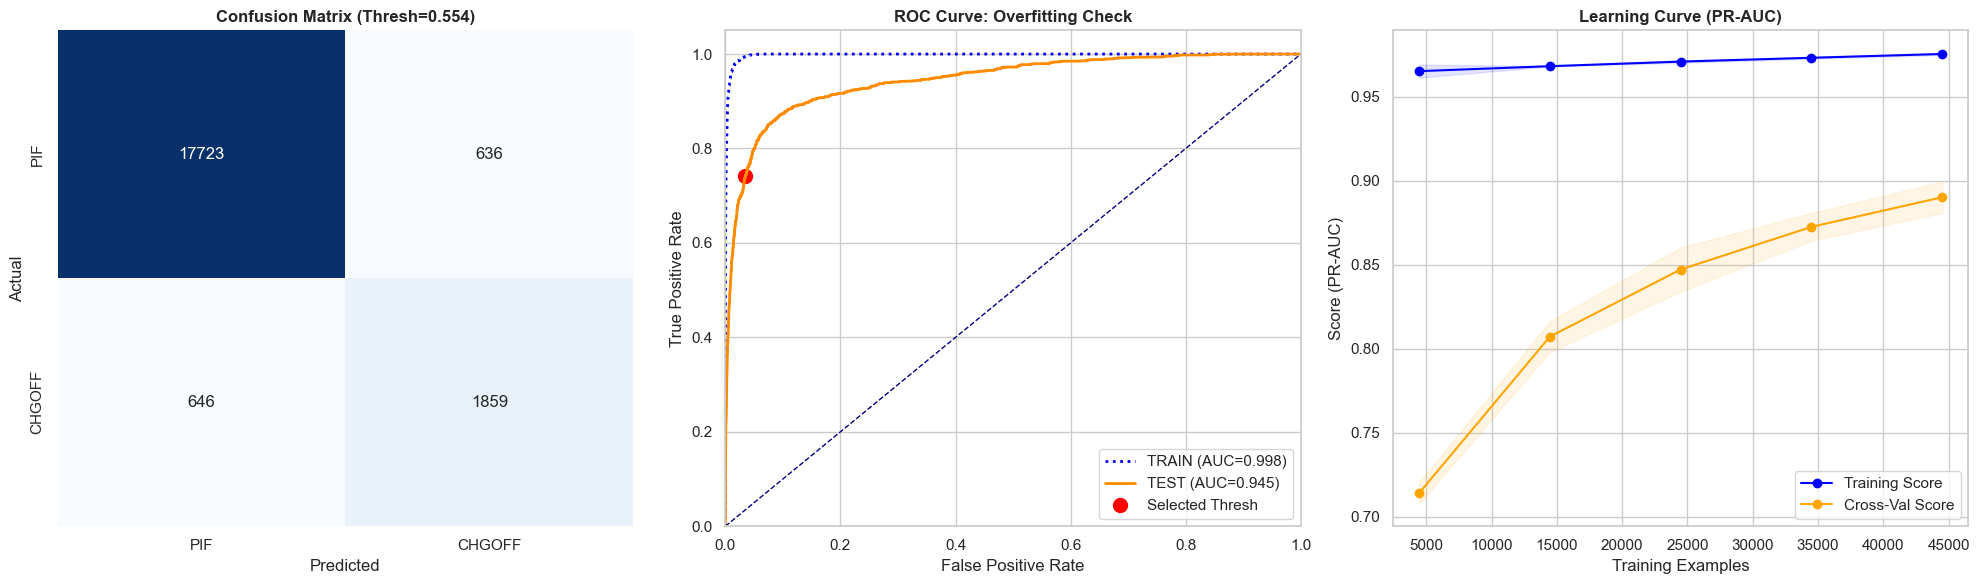

[INFO] MLflow Run Completed. Artifacts saved to ROC_LR_CM_v1.png


In [10]:
from sklearn.model_selection import learning_curve

plt.figure(figsize=(20, 6))

# CM
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix (Thresh={optimal_thresh:.3f})', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['PIF', 'CHGOFF'])
plt.yticks([0.5, 1.5], ['PIF', 'CHGOFF'])

# ROC
plt.subplot(1, 3, 2)

y_proba_train = final_model.predict_proba(X_train)[:, 1]
fpr_train, tpr_train, _ = roc_curve(y_train, y_proba_train)
auc_train = roc_auc_score(y_train, y_proba_train)

fpr_test, tpr_test, thresholds_roc = roc_curve(y_test, y_proba)
auc_test = roc_auc_score(y_test, y_proba)

plt.plot(fpr_train, tpr_train, color='blue', lw=2, linestyle=':', label=f'TRAIN (AUC={auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'TEST (AUC={auc_test:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')

closest_zero = np.argmin(np.abs(thresholds_roc - optimal_thresh))
plt.scatter(fpr_test[closest_zero], tpr_test[closest_zero], s=100, c='red', marker='o', label=f'Selected Thresh')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Overfitting Check', fontweight='bold')
plt.legend(loc="lower right")

# LR
plt.subplot(1, 3, 3)
print("Generating Learning Curve... (This may take a moment)")

train_sizes, train_scores, test_scores = learning_curve(
    final_model, 
    X_train, y_train, 
    cv=3, 
    scoring='average_precision', 
    n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plotting
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="orange")
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Cross-Val Score")

plt.title("Learning Curve (PR-AUC)", fontweight='bold')
plt.xlabel("Training Examples")
plt.ylabel("Score (PR-AUC)")
plt.legend(loc="best")
plt.grid(True)

plt.tight_layout()
viz_path = "ROC_LR_CM_v1.png"
plt.savefig(viz_path)
mlflow.log_artifact(viz_path)
plt.show()

mlflow.end_run()
print(f"[INFO] MLflow Run Completed. Artifacts saved to {viz_path}")

## Ensemble Strategy

In [5]:
CONFIG_PARAMS = {
    'RandomForest': {
        'n_estimators': {'low': 100, 'high': 300},
        'max_depth': {'low': 5, 'high': 12},  # Turunkan max dari 20 ke 12
        'min_samples_leaf': {'low': 10, 'high': 50}, # Naikkan min samples (biar ga hafal noise)
        'min_samples_split': {'low': 20, 'high': 100}
    },
    'XGBoost': {
        'n_estimators': {'low': 100, 'high': 300},
        'max_depth': {'low': 3, 'high': 8}, # Depth rendah = Less Overfit
        'learning_rate': {'low': 0.01, 'high': 0.1},
        'subsample': {'low': 0.5, 'high': 0.8}, # Sampling data
        'colsample_bytree': {'low': 0.5, 'high': 0.8}, # Sampling fitur
        'gamma': {'low': 1, 'high': 10}, # Min loss reduction (Pruning agresif)
        'reg_alpha': {'low': 0.1, 'high': 10.0}, # L1 Regularization (Lasso)
        'reg_lambda': {'low': 1.0, 'high': 10.0} # L2 Regularization (Ridge)
    },
    'LightGBM': {
        'n_estimators': {'low': 100, 'high': 300},
        'num_leaves': {'low': 20, 'high': 50}, # Batasi daun
        'max_depth': {'low': 3, 'high': 8},
        'learning_rate': {'low': 0.01, 'high': 0.1},
        'min_child_samples': {'low': 20, 'high': 100}, # Min data per daun besar
        'reg_alpha': {'low': 0.1, 'high': 10.0}, # L1
        'reg_lambda': {'low': 1.0, 'high': 10.0} # L2
    },
    'CatBoost': {
        'iterations': {'low': 100, 'high': 300},
        'depth': {'low': 3, 'high': 8},
        'learning_rate': {'low': 0.01, 'high': 0.1},
        'l2_leaf_reg': {'low': 3.0, 'high': 15.0}, # L2 (Ridge) diperkuat
        'random_strength': {'low': 1, 'high': 10}
    },
    'LogisticReg': {
        'C': {'low': 0.001, 'high': 1.0} # C kecil = Regularisasi Kuat
    }
}

In [6]:
def generate_shap_plots(model, X_sample, model_name):
    print(f"   Generating SHAP values for {model_name}...")
    
    try:
        if model_name == 'RandomForest':
    
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample, check_additivity=False)

            if isinstance(shap_values, list):
                shap_values_to_plot = shap_values[1]
            else:
                shap_values_to_plot = shap_values

        elif model_name in ['XGBoost', 'LightGBM', 'CatBoost']:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
            shap_values_to_plot = shap_values
            
        elif model_name == 'LogisticReg':
            explainer = shap.LinearExplainer(model, X_sample)
            shap_values = explainer.shap_values(X_sample)
            shap_values_to_plot = shap_values
            
        else:
            explainer = shap.Explainer(model, X_sample)
            shap_values = explainer(X_sample)
            shap_values_to_plot = shap_values

        # Plot Summary (Beeswarm)
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values_to_plot, X_sample, show=False)
        plt.title(f"SHAP Feature Importance: {model_name}", fontsize=14)
        plt.tight_layout()
        
        plot_path = f"SHAP_{model_name}.png"
        plt.savefig(plot_path, bbox_inches='tight')
        plt.close()
        
        mlflow.log_artifact(plot_path)
        os.remove(plot_path)
        print(f"      -> SHAP plot saved.")
        
    except Exception as e:
        print(f"      [WARN] Could not generate SHAP for {model_name}: {e}")

def plot_learning_curve_individual(estimator, X, y, title, cv=3):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring='average_precision', 
        n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Score")
    ax.plot(train_sizes, test_mean, 'o-', color="orange", label="Cross-Val Score")
    
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="orange")
    
    ax.set_title(f"Learning Curve (PR-AUC): {title}")
    ax.set_xlabel("Training Examples")
    ax.set_ylabel("PR-AUC Score")
    ax.legend(loc="best")
    ax.grid(True)
    return fig

def evaluate_performance(y_test, y_pred, y_proba, title="Model"):
    print(f"\n=== REPORT: {title} ===")
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(rec, prec)
    f1 = f1_score(y_test, y_pred)
    
    print(f"Test Accuracy : {acc:.4f}")
    print(f"ROC-AUC       : {roc:.4f}")
    print(f"PR-AUC        : {pr_auc:.4f}")
    print("-" * 40)
    print(classification_report(y_test, y_pred))
    
    # Logging Metrics ke MLflow
    mlflow.log_metrics({
        f"{title}_acc": acc,
        f"{title}_roc_auc": roc,
        f"{title}_pr_auc": pr_auc,
        f"{title}_f1": f1
    })
    
    # Plotting Individual
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'CM - {title}')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={roc:.3f}')
    axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[1].set_title(f'ROC - {title}')
    axes[1].legend()
    
    # Precision-Recall Curve
    axes[2].plot(rec, prec, color='green', lw=2, label=f'PR-AUC={pr_auc:.3f}')
    axes[2].set_title(f'PR Curve - {title}')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend()
    
    plt.tight_layout()
    plot_filename = f"Eval_{title.replace(' ', '_')}.png"
    plt.savefig(plot_filename)
    mlflow.log_artifact(plot_filename)
    plt.show()
    os.remove(plot_filename) # Cleanup
    
    return {
        'Model': title,
        'Accuracy': acc,
        'ROC_AUC': roc,
        'PR_AUC': pr_auc,
        'F1': f1,
        'y_proba': y_proba 
    }

def save_model_force(model_data, filename):
    full_path = os.path.join(config.MODEL_SAVE_PATH, filename)
    if os.path.exists(full_path):
        try:
            os.remove(full_path)
        except OSError:
            pass
    joblib.dump(model_data, full_path)
    mlflow.log_artifact(full_path, artifact_path='ensemble model')
    print(f"   [SAVE] Saved to: {filename}")

def tune_and_train(model_name, X, y, n_trials=20): 

    print(f"\n" + "="*60)
    print(f" TUNING & TRAINING: {model_name.upper()}")
    print("="*60)
    
    cfg = CONFIG_PARAMS[model_name]
    
    def objective_sub(trial):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            
            if model_name == 'RandomForest':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', cfg['n_estimators']['low'], cfg['n_estimators']['high']),
                    'max_depth': trial.suggest_int('max_depth', cfg['max_depth']['low'], cfg['max_depth']['high']),
                    'min_samples_split': trial.suggest_int('min_samples_split', cfg['min_samples_split']['low'], cfg['min_samples_split']['high']),
                    'min_samples_leaf': trial.suggest_int('min_samples_leaf', cfg['min_samples_leaf']['low'], cfg['min_samples_leaf']['high']),
                    'n_jobs': -1, 'random_state': 42, 'class_weight': 'balanced'
                }
                clf = RandomForestClassifier(**params)
                
            elif model_name == 'XGBoost':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', cfg['n_estimators']['low'], cfg['n_estimators']['high']),
                    'max_depth': trial.suggest_int('max_depth', cfg['max_depth']['low'], cfg['max_depth']['high']),
                    'learning_rate': trial.suggest_float('learning_rate', cfg['learning_rate']['low'], cfg['learning_rate']['high']),
                    'subsample': trial.suggest_float('subsample', cfg['subsample']['low'], cfg['subsample']['high']),
                    'colsample_bytree': trial.suggest_float('colsample_bytree', cfg['colsample_bytree']['low'], cfg['colsample_bytree']['high']),
                    'gamma': trial.suggest_float('gamma', cfg['gamma']['low'], cfg['gamma']['high']),
                    'reg_alpha': trial.suggest_float('reg_alpha', cfg['reg_alpha']['low'], cfg['reg_alpha']['high']),
                    'reg_lambda': trial.suggest_float('reg_lambda', cfg['reg_lambda']['low'], cfg['reg_lambda']['high']),
                    'n_jobs': -1, 'random_state': 42, 'eval_metric': 'logloss'
                }
                clf = XGBClassifier(**params)
            
            elif model_name == 'LightGBM':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', cfg['n_estimators']['low'], cfg['n_estimators']['high']),
                    'num_leaves': trial.suggest_int('num_leaves', cfg['num_leaves']['low'], cfg['num_leaves']['high']),
                    'max_depth': trial.suggest_int('max_depth', cfg['max_depth']['low'], cfg['max_depth']['high']),
                    'learning_rate': trial.suggest_float('learning_rate', cfg['learning_rate']['low'], cfg['learning_rate']['high']),
                    'min_child_samples': trial.suggest_int('min_child_samples', cfg['min_child_samples']['low'], cfg['min_child_samples']['high']),
                    'reg_alpha': trial.suggest_float('reg_alpha', cfg['reg_alpha']['low'], cfg['reg_alpha']['high']),
                    'reg_lambda': trial.suggest_float('reg_lambda', cfg['reg_lambda']['low'], cfg['reg_lambda']['high']),
                    'n_jobs': -1, 'random_state': 42, 'verbose': -1, 'class_weight': 'balanced'
                }
                clf = LGBMClassifier(**params)
                
            elif model_name == 'CatBoost':
                params = {
                    'iterations': trial.suggest_int('iterations', cfg['iterations']['low'], cfg['iterations']['high']),
                    'depth': trial.suggest_int('depth', cfg['depth']['low'], cfg['depth']['high']),
                    'learning_rate': trial.suggest_float('learning_rate', cfg['learning_rate']['low'], cfg['learning_rate']['high']),
                    'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', cfg['l2_leaf_reg']['low'], cfg['l2_leaf_reg']['high']),
                    'random_strength': trial.suggest_float('random_strength', cfg['random_strength']['low'], cfg['random_strength']['high']),
                    'verbose': 0, 'random_state': 42, 'allow_writing_files': False,
                    'auto_class_weights': 'Balanced'
                }
                clf = CatBoostClassifier(**params)
                
            elif model_name == 'LogisticReg':
                params = {
                    'C': trial.suggest_float('C', cfg['C']['low'], cfg['C']['high'], log=True),
                    'solver': 'liblinear', 'class_weight': 'balanced', 'random_state': 42
                }
                clf = LogisticRegression(**params)
            
            return cross_val_score(clf, X, y, cv=3, scoring='average_precision', n_jobs=-1).mean()

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective_sub, n_trials=n_trials, show_progress_bar=True)
    
    best_params = study.best_params
    print(f"  Best CV Score (PR-AUC): {study.best_value:.4f}")
    
    # Refit
    print(f"  Refitting {model_name} on Full Train Data...")
    if model_name == 'RandomForest': final_clf = RandomForestClassifier(**best_params, n_jobs=-1, random_state=42, class_weight='balanced')
    elif model_name == 'XGBoost': final_clf = XGBClassifier(**best_params, n_jobs=-1, random_state=42, eval_metric='logloss')
    elif model_name == 'LightGBM': final_clf = LGBMClassifier(**best_params, n_jobs=-1, random_state=42, verbose=-1, class_weight='balanced')
    elif model_name == 'CatBoost': final_clf = CatBoostClassifier(**best_params, verbose=0, random_state=42, allow_writing_files=False, auto_class_weights='Balanced')
    elif model_name == 'LogisticReg': final_clf = LogisticRegression(**best_params, solver='liblinear', class_weight='balanced', random_state=42)
    
    final_clf.fit(X, y)
    mlflow.log_params({f"tuned_{model_name}_{k}": v for k, v in best_params.items()})
    
    return final_clf

### Base Model Tuning

In [7]:
if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name='Base_Models_Tuning_Evaluation-v2') as run:
    print(f"\n>>> [MLFLOW] Started Run ID: {run.info.run_id}")

    X_tr_ens, y_tr_ens = X_train, y_train
    X_val_ens, y_val_ens = X_val, y_val
    
    
    if isinstance(X_test, pd.DataFrame):
        X_shap_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)
    else:
        X_shap_sample = pd.DataFrame(X_test).sample(n=min(500, len(X_test)), random_state=42)

    print(f"   Train Ensemble Shape : {X_tr_ens.shape}")
    print(f"   Valid Ensemble Shape : {X_val_ens.shape} (Used for Weight Optimization)")
    print(f"   Test Shape           : {X_test.shape} (Final Evaluation)")
    
    mlflow.log_param("Train_Ensemble_Size", X_tr_ens.shape[0])
    mlflow.log_param("Validate_Ensemble_Size", X_val_ens.shape[0])
    mlflow.log_param("Test_Ensemble_Size", X_test.shape[0])


>>> [MLFLOW] Started Run ID: e0a3445614b54d38a8bd49e62280c312
   Train Ensemble Shape : (66762, 41)
   Valid Ensemble Shape : (16691, 41) (Used for Weight Optimization)
   Test Shape           : (20864, 41) (Final Evaluation)



 TUNING & TRAINING: RANDOMFOREST


Best trial: 18. Best value: 0.833158: 100%|██████████| 20/20 [01:18<00:00,  3.93s/it]


  Best CV Score (PR-AUC): 0.8332
  Refitting RandomForest on Full Train Data...
   Generating Learning Curve for RandomForest...
   Generating SHAP values for RandomForest...
      -> SHAP plot saved.

 TUNING & TRAINING: XGBOOST


Best trial: 16. Best value: 0.869461: 100%|██████████| 20/20 [00:17<00:00,  1.16it/s]


  Best CV Score (PR-AUC): 0.8695
  Refitting XGBoost on Full Train Data...
   Generating Learning Curve for XGBoost...
   Generating SHAP values for XGBoost...
      -> SHAP plot saved.

 TUNING & TRAINING: LIGHTGBM


...

Best trial: 16. Best value: 0.913581: 100%|██████████| 20/20 [01:01<00:00,  3.07s/it]


  Best CV Score (PR-AUC): 0.9136
  Refitting CatBoost on Full Train Data...
   Generating Learning Curve for CatBoost...
   Generating SHAP values for CatBoost...
      -> SHAP plot saved.

 TUNING & TRAINING: LOGISTICREG


Best trial: 13. Best value: 0.465695: 100%|██████████| 20/20 [00:12<00:00,  1.65it/s]


  Best CV Score (PR-AUC): 0.4657
  Refitting LogisticReg on Full Train Data...
   Generating Learning Curve for LogisticReg...
   Generating SHAP values for LogisticReg...
      -> SHAP plot saved.

>>> Generating Predictions for Base Evaluation...

=== REPORT: Base: RandomForest ===
Test Accuracy : 0.8885
ROC-AUC       : 0.9430
PR-AUC        : 0.7973
----------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.89      0.93     18359
           1       0.52      0.88      0.65      2505

    accuracy                           0.89     20864
   macro avg       0.75      0.89      0.79     20864
weighted avg       0.93      0.89      0.90     20864



<Figure size 1000x600 with 0 Axes>

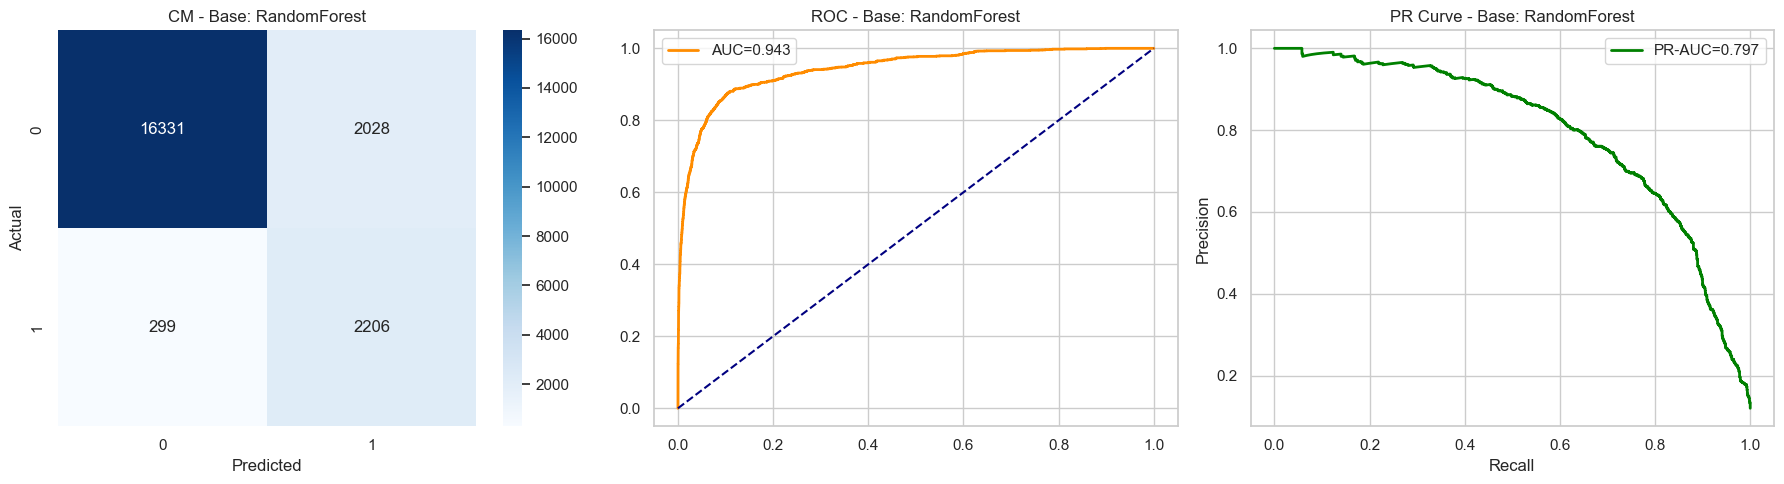


=== REPORT: Base: XGBoost ===
Test Accuracy : 0.9584
ROC-AUC       : 0.9583
PR-AUC        : 0.8642
----------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     18359
           1       0.85      0.79      0.82      2505

    accuracy                           0.96     20864
   macro avg       0.91      0.89      0.90     20864
weighted avg       0.96      0.96      0.96     20864



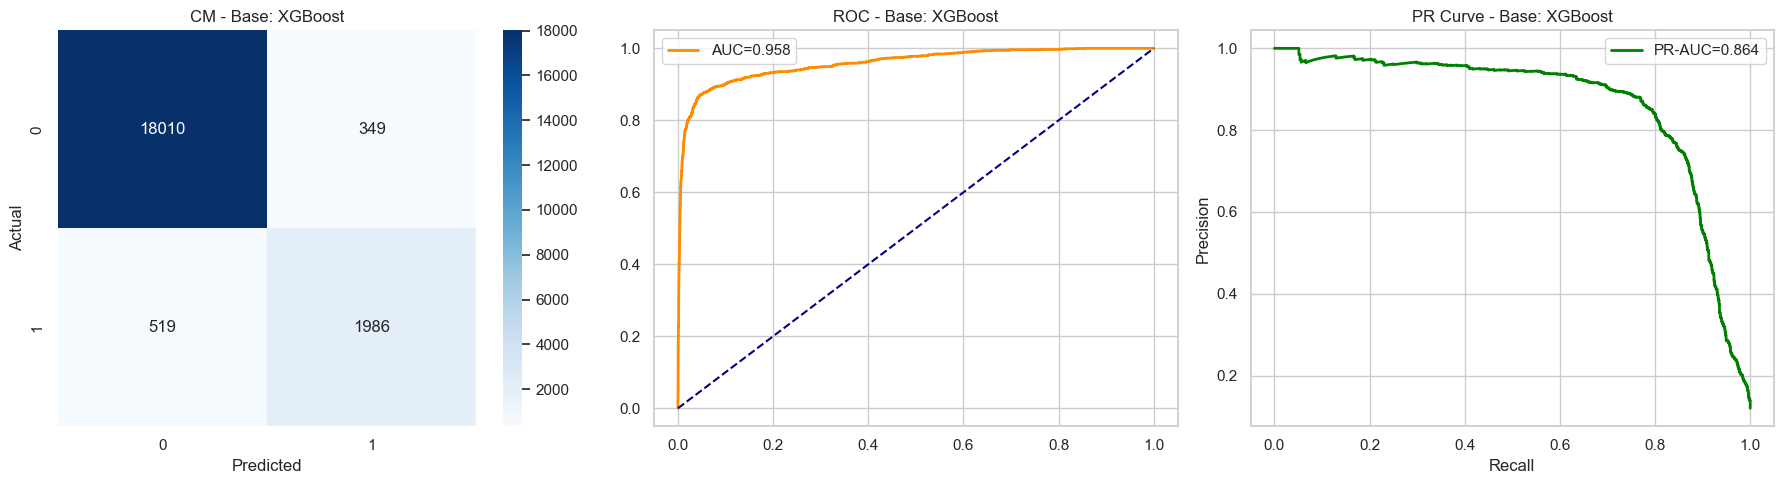


=== REPORT: Base: LightGBM ===
Test Accuracy : 0.9481
ROC-AUC       : 0.9613
PR-AUC        : 0.8721
----------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     18359
           1       0.73      0.89      0.80      2505

    accuracy                           0.95     20864
   macro avg       0.86      0.92      0.89     20864
weighted avg       0.95      0.95      0.95     20864



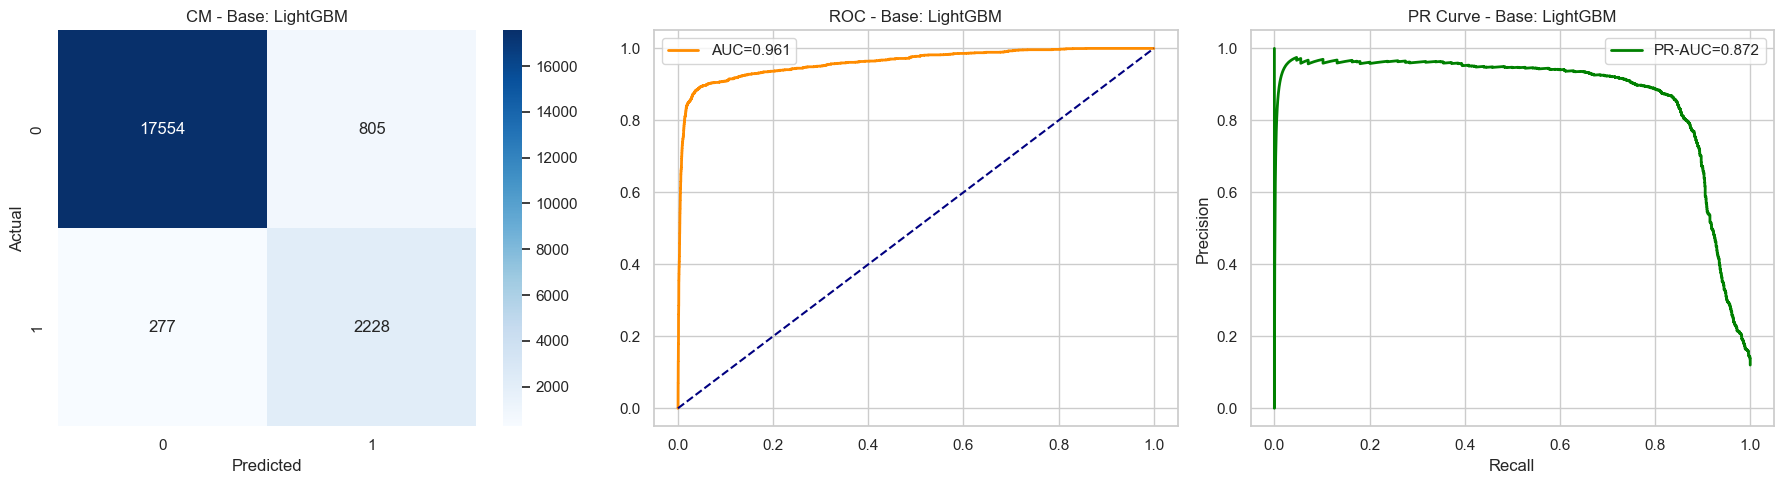


=== REPORT: Base: CatBoost ===
Test Accuracy : 0.9512
ROC-AUC       : 0.9611
PR-AUC        : 0.8789
----------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     18359
           1       0.75      0.89      0.81      2505

    accuracy                           0.95     20864
   macro avg       0.87      0.92      0.89     20864
weighted avg       0.96      0.95      0.95     20864



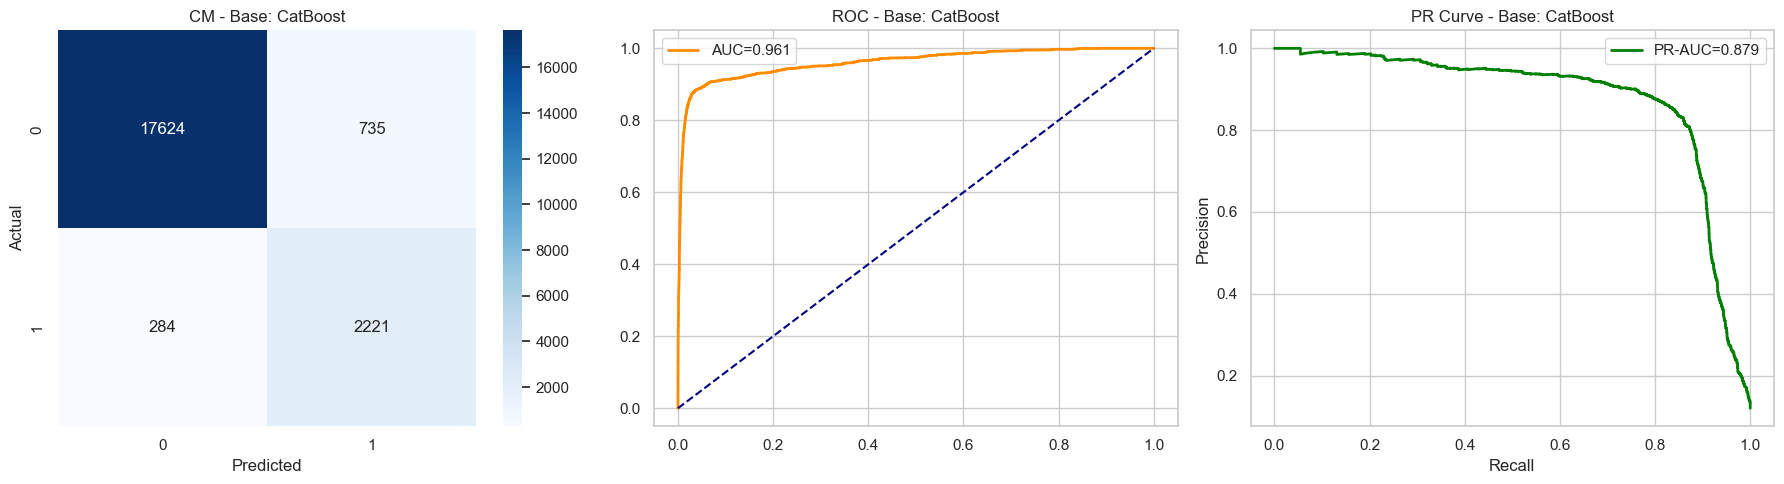


=== REPORT: Base: LogisticReg ===
Test Accuracy : 0.6198
ROC-AUC       : 0.8227
PR-AUC        : 0.3729
----------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.58      0.73     18359
           1       0.22      0.88      0.36      2505

    accuracy                           0.62     20864
   macro avg       0.60      0.73      0.54     20864
weighted avg       0.88      0.62      0.69     20864



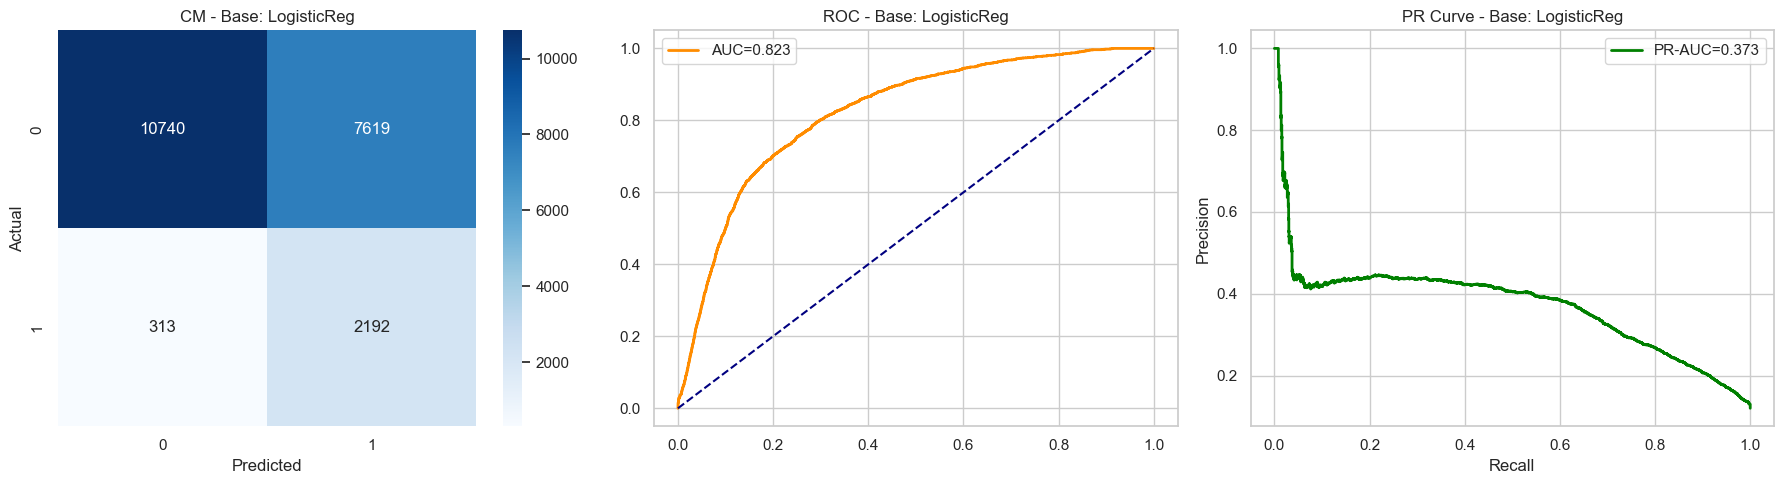

In [8]:
last_run = mlflow.last_active_run()

if last_run:
    with mlflow.start_run(run_id=last_run.info.run_id):
        X_tr_ens, y_tr_ens = X_train, y_train
        X_val_ens, y_val_ens = X_val, y_val
        
        mlflow.log_param("Train_Ensemble_Size", X_tr_ens.shape[0])
        
        model_list = ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost', 'LogisticReg']
        squad = {}
        
        # Tuning Loop
        for name in model_list:
            # Tuning & Training
            model = tune_and_train(name, X_tr_ens, y_tr_ens, n_trials=20)
            squad[name] = model
            
            # Learning Curve Generation
            print(f"   Generating Learning Curve for {name}...")
            fig_lc = plot_learning_curve_individual(model, X_tr_ens, y_tr_ens, title=name)
            lc_path = f"LC_{name}.png"
            fig_lc.savefig(lc_path)
            mlflow.log_artifact(lc_path, artifact_path='Learning Curve (Base Model)')
            plt.close(fig_lc)
            os.remove(lc_path)
            
            generate_shap_plots(model, X_shap_sample, name)
        # Generating Predictions
        print("\n>>> Generating Predictions for Base Evaluation...")
        p_val = {k: v.predict_proba(X_val_ens)[:, 1] for k, v in squad.items()}
        p_test = {k: v.predict_proba(X_test)[:, 1] for k, v in squad.items()}
        
        # Evaluate Base Models
        leaderboard = []
        for name, model in squad.items():
            pred = model.predict(X_test)
            metrics = evaluate_performance(y_test, pred, p_test[name], title=f"Base: {name}")
            leaderboard.append(metrics)

        # Save Squad
        joblib.dump(squad, os.path.join(config.MODEL_SAVE_PATH, 'squad_models.pkl'))
        mlflow.log_artifact(os.path.join(config.MODEL_SAVE_PATH, 'squad_models.pkl'))

In [9]:
def objective_ensemble(trial):
        w_rf  = trial.suggest_float('w_rf', 0.0, 1.0)
        w_xgb = trial.suggest_float('w_xgb', 0.0, 1.0)
        w_lgbm = trial.suggest_float('w_lgbm', 0.0, 1.0)
        w_cat = trial.suggest_float('w_cat', 0.0, 1.0)
        w_lr  = trial.suggest_float('w_lr', 0.0, 1.0)
        
        # Suggest Threshold
        thresh = trial.suggest_float('threshold', 0.30, 0.70)
        
        # Weighted Average Probabilities (Validation Set)
        denom = w_rf + w_xgb + w_lgbm + w_cat + w_lr + 1e-10
        weighted_prob = (w_rf*p_val['RandomForest'] + w_xgb*p_val['XGBoost'] + 
                         w_lgbm*p_val['LightGBM'] + w_cat*p_val['CatBoost'] + 
                         w_lr*p_val['LogisticReg']) / denom
        
        pred_final = (weighted_prob >= thresh).astype(int)
        return f1_score(y_val_ens, pred_final)

if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name='Ensemble_Strategy') as run:
    print(f"\n>>> [MLFLOW] Started Run ID: {run.info.run_id}")
    
    X_val_ens, y_val_ens = X_val, y_val
    
    mlflow.log_param("Ensemble_Val_Size", len(X_val_ens))


>>> [MLFLOW] Started Run ID: c40f61442f614a7eb52245d912171ef4


### Ensemble Soft Voting 


>>> Strategy 1: Soft Voting (Average)...

=== REPORT: Ensemble: Soft Voting ===
Test Accuracy : 0.9468
ROC-AUC       : 0.9579
PR-AUC        : 0.8649
----------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     18359
           1       0.73      0.88      0.80      2505

    accuracy                           0.95     20864
   macro avg       0.86      0.92      0.88     20864
weighted avg       0.95      0.95      0.95     20864



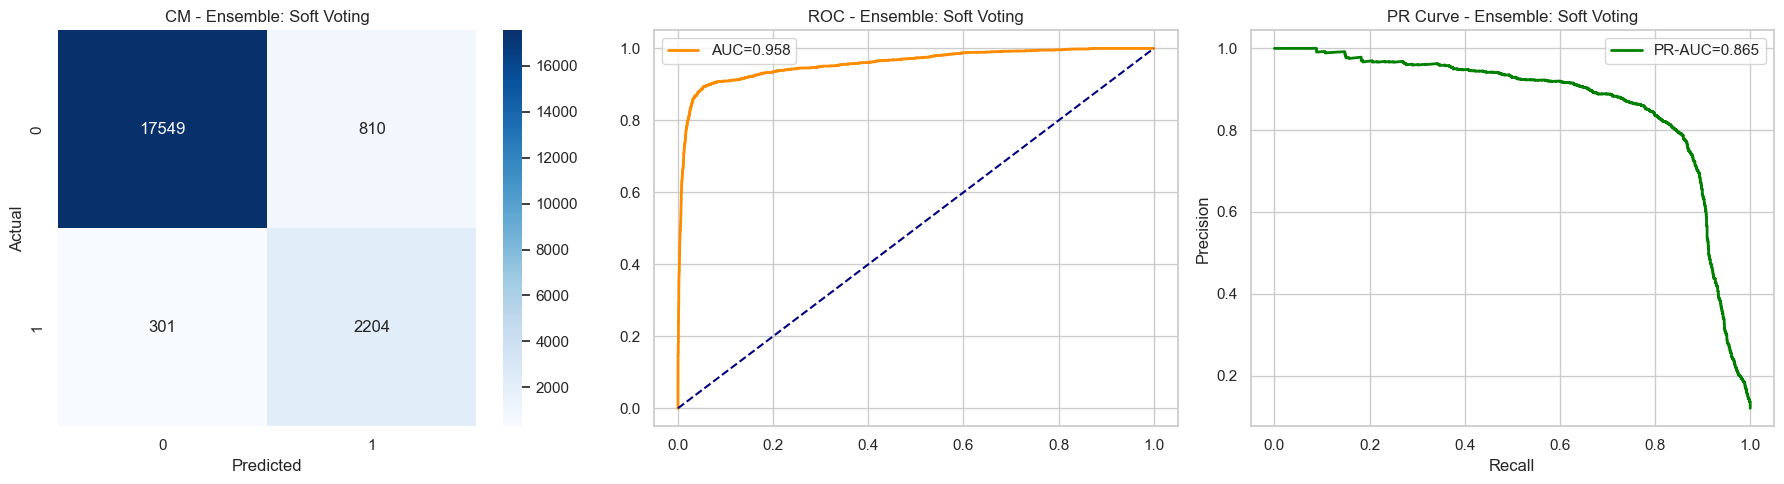

In [10]:
last_run = mlflow.last_active_run()
if last_run :
   with mlflow.start_run(run_id=last_run.info.run_id) :
    print("\n>>> Strategy 1: Soft Voting (Average)...")
    final_prob_vote = (p_test['RandomForest'] + p_test['XGBoost'] + p_test['LightGBM'] + p_test['CatBoost'] + p_test['LogisticReg']) / 5
    final_pred_vote = (final_prob_vote >= 0.5).astype(int) # Default Threshold
    metrics_vote = evaluate_performance(y_test, final_pred_vote, final_prob_vote, title="Ensemble: Soft Voting")
    leaderboard.append(metrics_vote)
    mlflow.log_dict(metrics_vote, "soft_voting_metrics.json")

### Ensemble Hill Climbing


>>> Strategy 2: Hill Climbing (Optuna)...

=== REPORT: Ensemble: Hill Climbing ===
Test Accuracy : 0.9629
ROC-AUC       : 0.9624
PR-AUC        : 0.8777
----------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18359
           1       0.84      0.85      0.85      2505

    accuracy                           0.96     20864
   macro avg       0.91      0.91      0.91     20864
weighted avg       0.96      0.96      0.96     20864



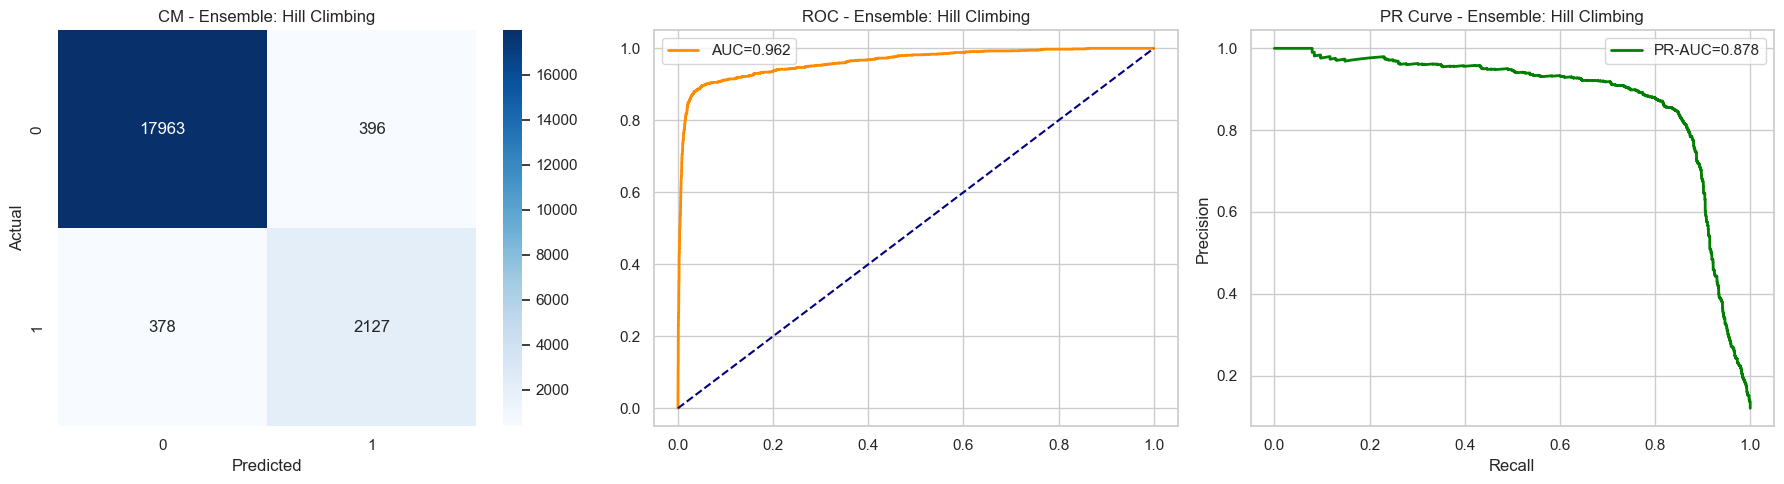

   [SAVE] Saved to: ensemble_hill_climbing.pkl


In [11]:
last_run = mlflow.last_active_run()
if last_run :
   with mlflow.start_run(run_id=last_run.info.run_id) :

    print("\n>>> Strategy 2: Hill Climbing (Optuna)...")
    study_hc = optuna.create_study(direction='maximize')
    study_hc.optimize(objective_ensemble, n_trials=50, show_progress_bar=False)
    best_w_hc = study_hc.best_params
        
    # Predict
    thresh_hc = best_w_hc['threshold']
    denom_hc = best_w_hc['w_rf'] + best_w_hc['w_xgb'] + best_w_hc['w_lgbm'] + best_w_hc['w_cat'] + best_w_hc['w_lr']
        
    final_prob_hc = (best_w_hc['w_rf']*p_test['RandomForest'] + best_w_hc['w_xgb']*p_test['XGBoost'] + 
                    best_w_hc['w_lgbm']*p_test['LightGBM'] + best_w_hc['w_cat']*p_test['CatBoost'] + 
                    best_w_hc['w_lr']*p_test['LogisticReg']) / denom_hc
    final_pred_hc = (final_prob_hc >= thresh_hc).astype(int)
        
    metrics_hc = evaluate_performance(y_test, final_pred_hc, final_prob_hc, title="Ensemble: Hill Climbing")
    leaderboard.append(metrics_hc)
    save_model_force({'model': squad, 'weights': best_w_hc}, 'ensemble_hill_climbing.pkl')
    mlflow.log_dict(metrics_vote, "hill_climbing_metrics.json")


>>> Strategy 3: Genetic Algorithm (CMA-ES)...

=== REPORT: Ensemble: CMA-ES ===
Test Accuracy : 0.9606
ROC-AUC       : 0.9620
PR-AUC        : 0.8764
----------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18359
           1       0.82      0.85      0.84      2505

    accuracy                           0.96     20864
   macro avg       0.90      0.91      0.91     20864
weighted avg       0.96      0.96      0.96     20864



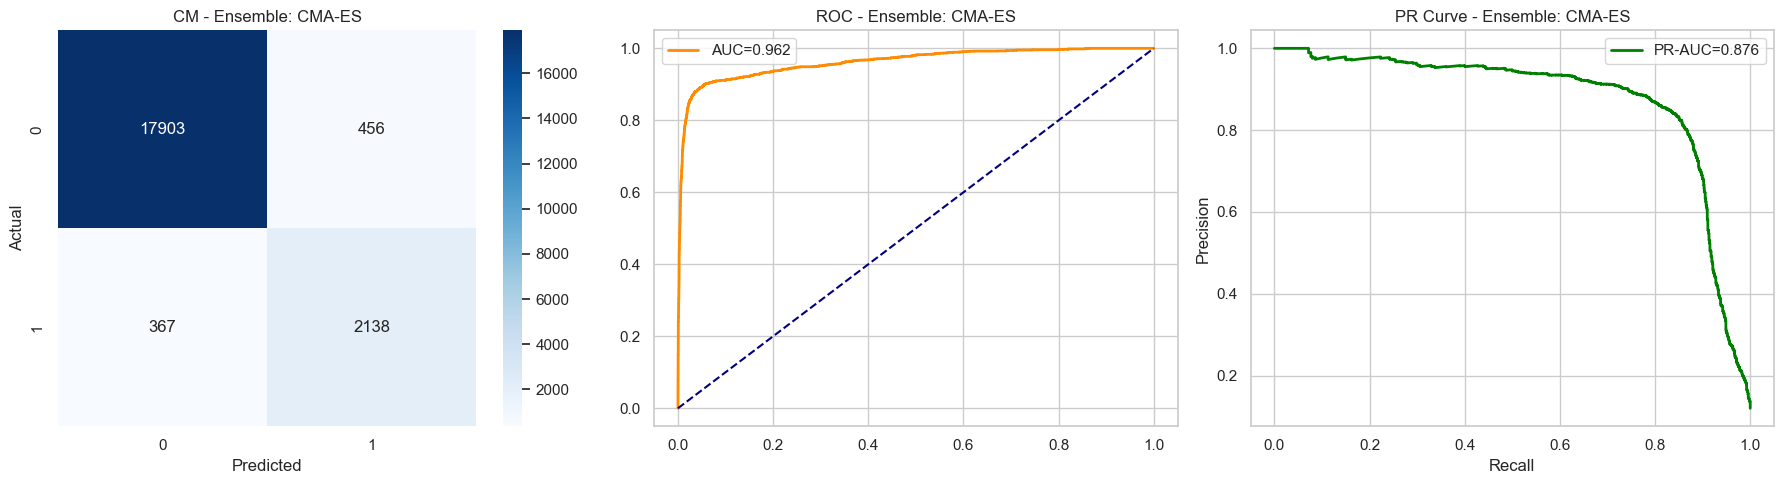

   [SAVE] Saved to: ensemble_cmaes.pkl


In [12]:
last_run = mlflow.last_active_run()
if last_run:
    with mlflow.start_run(run_id=last_run.info.run_id):
        print("\n>>> Strategy 3: Genetic Algorithm (CMA-ES)...")
        sampler_ga = CmaEsSampler(seed=42)
        study_ga = optuna.create_study(direction='maximize', sampler=sampler_ga)
        study_ga.optimize(objective_ensemble, n_trials=50, show_progress_bar=False)
        best_w_ga = study_ga.best_params
            
        thresh_ga = best_w_ga['threshold']
        denom_ga = best_w_ga['w_rf'] + best_w_ga['w_xgb'] + best_w_ga['w_lgbm'] + best_w_ga['w_cat'] + best_w_ga['w_lr']
            
        final_prob_ga = (best_w_ga['w_rf']*p_test['RandomForest'] + best_w_ga['w_xgb']*p_test['XGBoost'] + 
                        best_w_ga['w_lgbm']*p_test['LightGBM'] + best_w_ga['w_cat']*p_test['CatBoost'] + 
                        best_w_ga['w_lr']*p_test['LogisticReg']) / denom_ga
        final_pred_ga = (final_prob_ga >= thresh_ga).astype(int)
            
        metrics_ga = evaluate_performance(y_test, final_pred_ga, final_prob_ga, title="Ensemble: CMA-ES")
        leaderboard.append(metrics_ga)
        save_model_force({'model': squad, 'weights': best_w_ga}, 'ensemble_cmaes.pkl')
        mlflow.log_dict(metrics_vote, "ga_cmaes_metrics.json")


>>> Strategy 4: NSGA-II Evolutionary...

=== REPORT: Ensemble: NSGA-II ===
Test Accuracy : 0.9606
ROC-AUC       : 0.9554
PR-AUC        : 0.8604
----------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18359
           1       0.84      0.84      0.84      2505

    accuracy                           0.96     20864
   macro avg       0.91      0.91      0.91     20864
weighted avg       0.96      0.96      0.96     20864



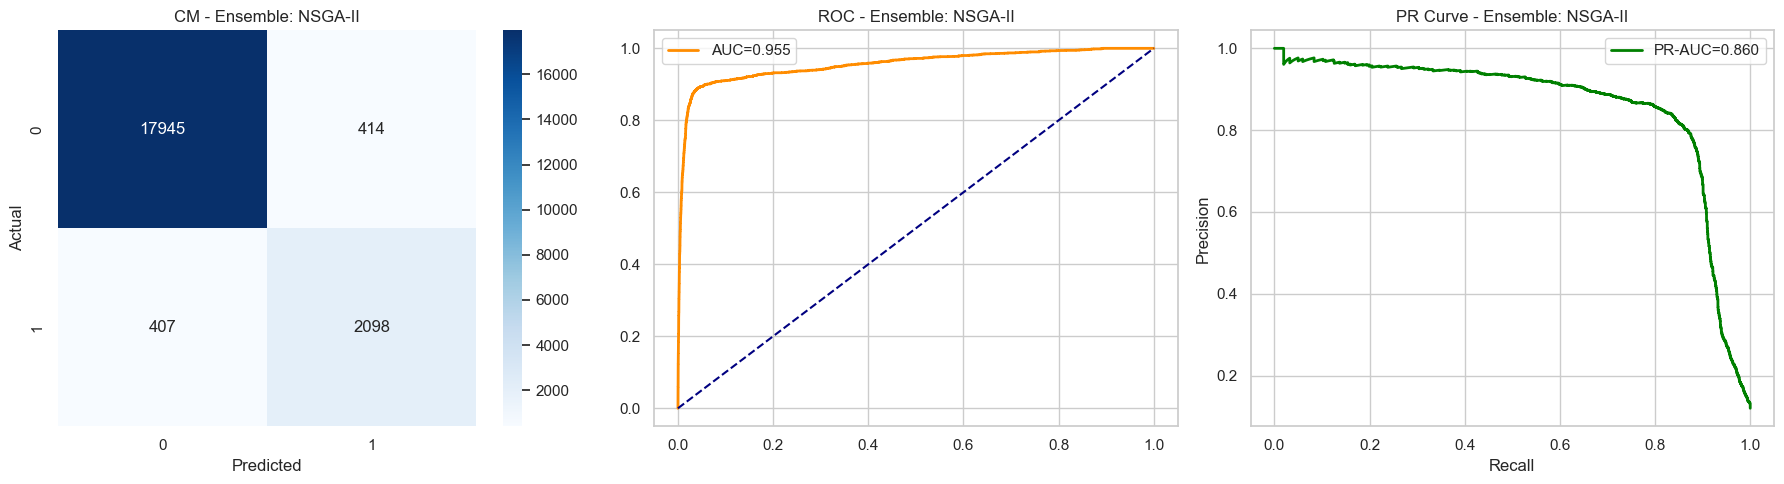

   [SAVE] Saved to: ensemble_nsga2.pkl


In [15]:
last_run = mlflow.last_active_run()
if last_run:
    with mlflow.start_run(run_id=last_run.info.run_id):
        print("\n>>> Strategy 4: NSGA-II Evolutionary...")
        sampler_nsga = NSGAIISampler(seed=42)
        study_nsga = optuna.create_study(direction='maximize', sampler=sampler_nsga)
        study_nsga.optimize(objective_ensemble, n_trials=50, show_progress_bar=False)
        best_w_nsga = study_nsga.best_params
        
        thresh_nsga = best_w_nsga['threshold']
        denom_nsga = best_w_nsga['w_rf'] + best_w_nsga['w_xgb'] + best_w_nsga['w_lgbm'] + best_w_nsga['w_cat'] + best_w_nsga['w_lr']
        
        final_prob_nsga = (best_w_nsga['w_rf']*p_test['RandomForest'] + best_w_nsga['w_xgb']*p_test['XGBoost'] + 
                        best_w_nsga['w_lgbm']*p_test['LightGBM'] + best_w_nsga['w_cat']*p_test['CatBoost'] + 
                        best_w_nsga['w_lr']*p_test['LogisticReg']) / denom_nsga
        final_pred_nsga = (final_prob_nsga >= thresh_nsga).astype(int)
        
        metrics_nsga = evaluate_performance(y_test, final_pred_nsga, final_prob_nsga, title="Ensemble: NSGA-II")
        leaderboard.append(metrics_nsga)
        save_model_force({'model': squad, 'weights': best_w_nsga}, 'ensemble_nsga2.pkl')
        mlflow.log_dict(metrics_vote, "ga_nsgaII_metrics.json")


FINAL LEADERBOARD (Base Models vs Ensembles)
                     Model  Accuracy   ROC_AUC    PR_AUC        F1
3           Base: CatBoost  0.951160  0.961059  0.878907  0.813404
6  Ensemble: Hill Climbing  0.962903  0.962365  0.877748  0.846062
7         Ensemble: CMA-ES  0.960554  0.961986  0.876423  0.838596
2           Base: LightGBM  0.948140  0.961312  0.872078  0.804623
5    Ensemble: Soft Voting  0.946750  0.957932  0.864873  0.798695
1            Base: XGBoost  0.958397  0.958321  0.864172  0.820661
0       Base: RandomForest  0.888468  0.943020  0.797304  0.654697
4        Base: LogisticReg  0.619824  0.822703  0.372941  0.355960


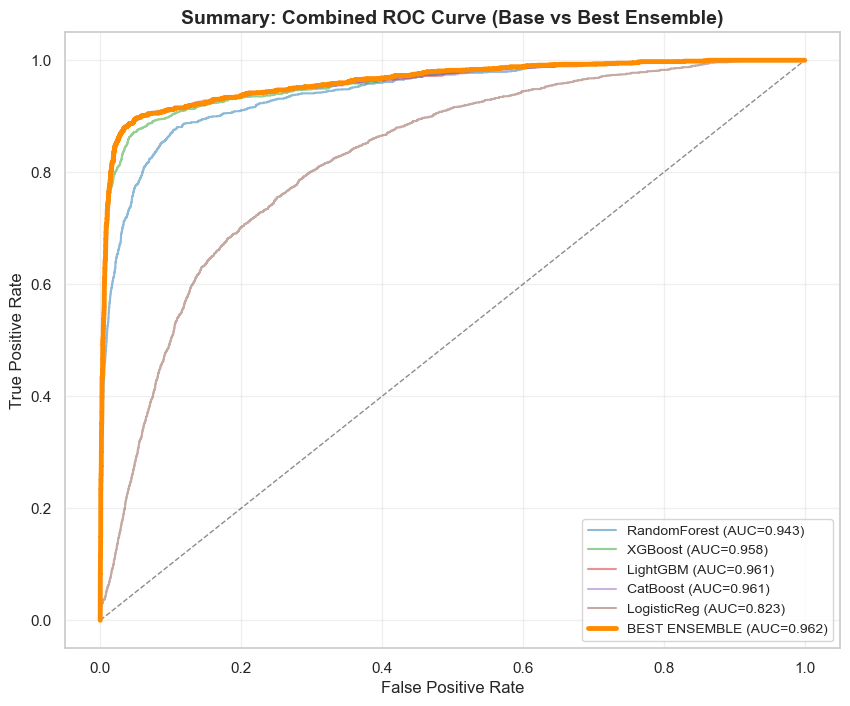

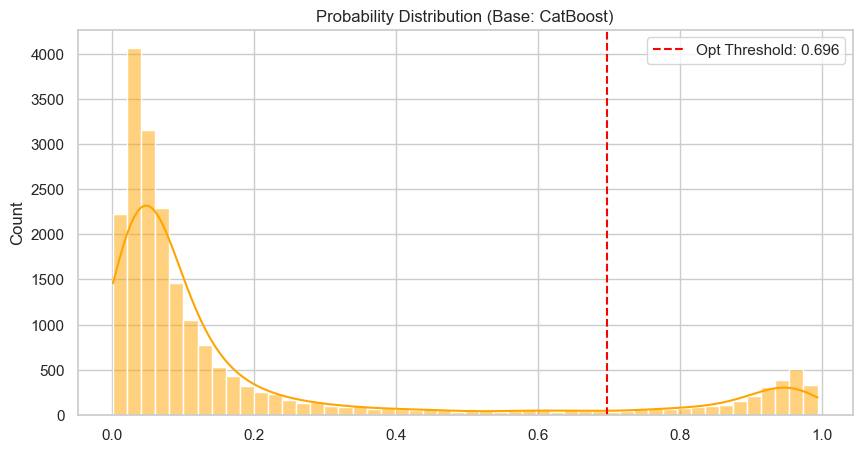

In [13]:
last_run = mlflow.last_active_run()
if last_run:
    with mlflow.start_run(run_id=last_run.info.run_id):
        print("\n" + "="*80)
        print("FINAL LEADERBOARD (Base Models vs Ensembles)")
        print("="*80)
        df_leaderboard = pd.DataFrame(leaderboard).sort_values('PR_AUC', ascending=False)
        print(df_leaderboard[['Model', 'Accuracy', 'ROC_AUC', 'PR_AUC', 'F1']])
        mlflow.log_table(df_leaderboard, "Final_Leaderboard.json")

        # Combined ROC Curve (Overlay)
        plt.figure(figsize=(10, 8))
        plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)

        # Plot Base Models
        colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
        for i, (name, model) in enumerate(squad.items()):
            fpr, tpr, _ = roc_curve(y_test, p_test[name])
            auc_score = roc_auc_score(y_test, p_test[name])
            
            plt.plot(fpr, tpr, color=colors[i % len(colors)], alpha=0.5, linewidth=1.5, 
                    label=f'{name} (AUC={auc_score:.3f})')

        # Plot Best Ensemble
        best_model_name = df_leaderboard.iloc[0]['Model']
        fpr_ens, tpr_ens, _ = roc_curve(y_test, final_prob_hc)
        auc_ens = roc_auc_score(y_test, final_prob_hc)
        
        plt.plot(fpr_ens, tpr_ens, color='darkorange', linewidth=3.5, 
                 label=f'BEST ENSEMBLE (AUC={auc_ens:.3f})')

        plt.xlabel('False Positive Rate', fontsize=12)
        plt.ylabel('True Positive Rate', fontsize=12)
        plt.title('Summary: Combined ROC Curve (Base vs Best Ensemble)', fontsize=14, fontweight='bold')
        plt.legend(loc="lower right", fontsize=10, frameon=True)
        plt.grid(True, alpha=0.3)
        
        roc_summary_path = "Summary_Combined_ROC.png"
        plt.savefig(roc_summary_path, dpi=300) 
        mlflow.log_artifact(roc_summary_path)
        plt.show()
        os.remove(roc_summary_path)

        plt.figure(figsize=(10, 5))
        sns.histplot(final_prob_hc, kde=True, bins=50, color='orange')
        plt.axvline(best_w_hc['threshold'], color='red', linestyle='--', label=f"Opt Threshold: {best_w_hc['threshold']:.3f}")
        plt.title(f"Probability Distribution ({best_model_name})")
        plt.legend()
        
        dist_path = "Top_Distribution.png"
        plt.savefig(dist_path)
        mlflow.log_artifact(dist_path)
        plt.show()
        os.remove(dist_path)

### Risk Trade Off Analysis

In [14]:
AVG_LOAN_AMOUNT = 100000  # Rata-rata pinjaman $100k
INTEREST_MARGIN = 0.10    # Margin bunga 10% (Keuntungan jika lancar)
LGD = 0.60                # Loss Given Default 60% (Kerugian pokok jika macet)

BASE_SCORE = 600
BASE_ODDS = 50.0  # 50 Good : 1 Bad
PDO = 20.0        # Points to Double the Odds

# Hitung Parameter Scorecard
FACTOR = PDO / np.log(2)
OFFSET = BASE_SCORE - (FACTOR * np.log(BASE_ODDS))

def convert_to_score(prob_default):

    prob_default = np.clip(prob_default, 1e-5, 0.99999)
    odds_good = (1 - prob_default) / prob_default
    score = OFFSET + (FACTOR * np.log(odds_good))
    return np.clip(score, 300, 850)

print("[INFO] Cell 1: Scaling Engine & Financial Assumptions Loaded.")

[INFO] Cell 1: Scaling Engine & Financial Assumptions Loaded.



>>> [MLFLOW] Started Run ID: 21260f0831d247d4a12a49f696f928d7

>>> Executing IRB Calibration for Top Models...
  Calibrating LightGBM...
  Calibrating CatBoost...
  Calibrating Ensemble_HC...


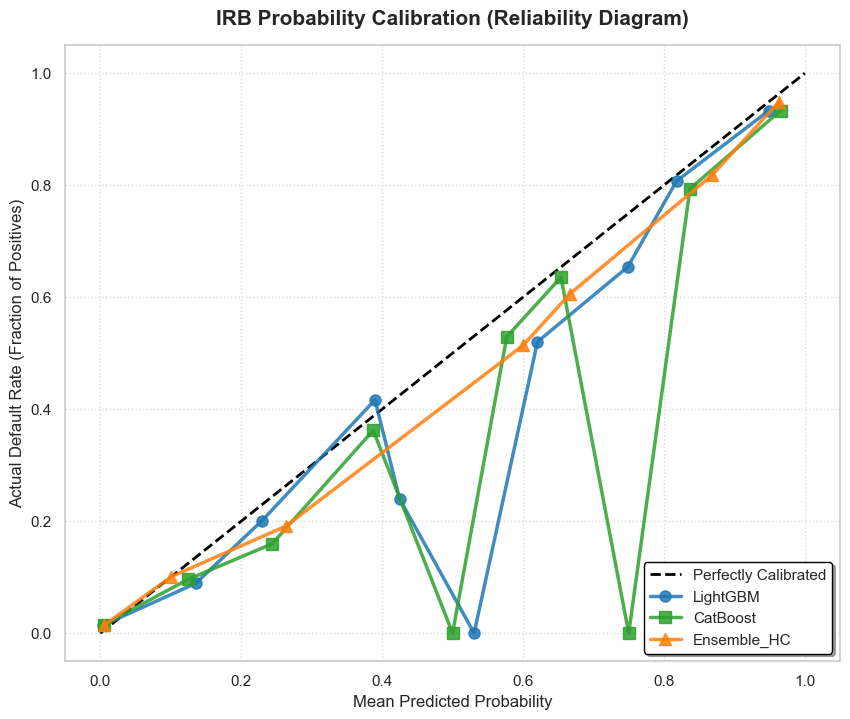

In [15]:
if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name='IRB_enchanment_plot') as run:
    print(f"\n>>> [MLFLOW] Started Run ID: {run.info.run_id}")
    print("\n>>> Executing IRB Calibration for Top Models...")
        
    denom_hc = best_w_hc['w_rf'] + best_w_hc['w_xgb'] + best_w_hc['w_lgbm'] + best_w_hc['w_cat'] + best_w_hc['w_lr']
    final_prob_hc_val = (
        best_w_hc['w_rf']*p_val['RandomForest'] + 
        best_w_hc['w_xgb']*p_val['XGBoost'] + 
        best_w_hc['w_lgbm']*p_val['LightGBM'] + 
        best_w_hc['w_cat']*p_val['CatBoost'] + 
        best_w_hc['w_lr']*p_val['LogisticReg']
    ) / denom_hc

    top_models = {
        'LightGBM': {'val': p_val['LightGBM'], 'test': p_test['LightGBM']},
        'CatBoost': {'val': p_val['CatBoost'], 'test': p_test['CatBoost']},
        'Ensemble_HC': {'val': final_prob_hc_val, 'test': final_prob_hc}
        }

    calibrated_results = {}
        
    plt.figure(figsize=(10, 8))
    plt.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=2, label="Perfectly Calibrated", zorder=1)
        
    colors = ['#1f77b4', '#2ca02c', '#ff7f0e'] 
    markers = ['o', 's', '^']
        
    for i, (name, probs) in enumerate(top_models.items()):
        print(f"  Calibrating {name}...")
            
        iso_reg = IsotonicRegression(out_of_bounds='clip')
        iso_reg.fit(probs['val'], y_val_ens)
            
        calibrated_prob_test = iso_reg.predict(probs['test'])
            
        fraction_of_positives, mean_predicted_value = calibration_curve(y_test, calibrated_prob_test, n_bins=10)
        
        plt.plot(mean_predicted_value, fraction_of_positives, marker=markers[i], linestyle='-', 
                color=colors[i], label=f"{name}", linewidth=2.5, markersize=8, alpha=0.85, zorder=2+i)
            
        credit_scores = convert_to_score(calibrated_prob_test)
        calibrated_results[name] = {'prob_calibrated': calibrated_prob_test, 'scores': credit_scores}
            
    plt.ylabel("Actual Default Rate (Fraction of Positives)", fontsize=12)
    plt.xlabel("Mean Predicted Probability", fontsize=12)
    plt.title("IRB Probability Calibration (Reliability Diagram)", fontsize=15, fontweight='bold', pad=15)
        
    plt.legend(loc="lower right", fontsize=11, frameon=True, framealpha=1.0, edgecolor='black', shadow=True)
    plt.grid(True, linestyle=':', alpha=0.7)
        
    calib_plot_path = "IRB_Calibration_Curve.png"
    plt.savefig(calib_plot_path, dpi=300, bbox_inches='tight')
    mlflow.log_artifact(calib_plot_path, artifact_path="Scorecard_Assets")
    plt.show()
    os.remove(calib_plot_path)


>>> Generating Scorecard Population Density...


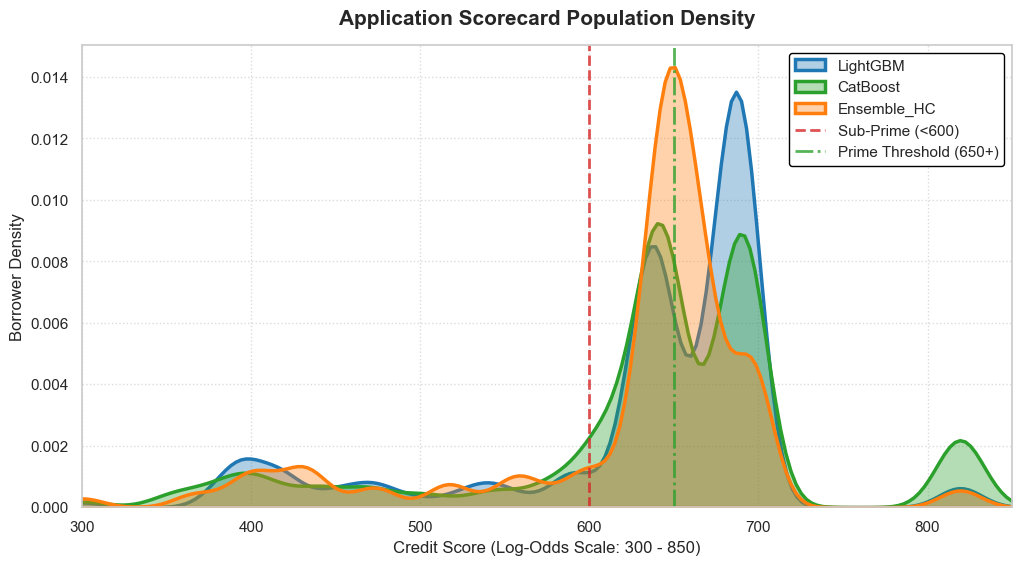

In [16]:
last_run = mlflow.last_active_run()

if last_run:
    with mlflow.start_run(run_id=last_run.info.run_id):
        print("\n>>> Generating Scorecard Population Density...")
        
        plt.figure(figsize=(12, 6))
        
        colors = ['#1f77b4', '#2ca02c', '#ff7f0e'] 
        for i, (name, res) in enumerate(calibrated_results.items()):
            sns.kdeplot(res['scores'], label=name, fill=True, color=colors[i], alpha=0.35, linewidth=2.5)
        
        plt.title("Application Scorecard Population Density", fontsize=15, fontweight='bold', pad=15)
        plt.xlabel("Credit Score (Log-Odds Scale: 300 - 850)", fontsize=12)
        plt.ylabel("Borrower Density", fontsize=12)
    
        plt.axvline(600, color='#d62728', linestyle='--', linewidth=2, alpha=0.8, label='Sub-Prime (<600)')
        plt.axvline(650, color='#2ca02c', linestyle='-.', linewidth=2, alpha=0.8, label='Prime Threshold (650+)')
        
        plt.legend(loc="upper right", fontsize=11, frameon=True, framealpha=1.0, edgecolor='black')
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.xlim(300, 850)
        
        score_dist_path = "Scorecard_Density.png"
        plt.savefig(score_dist_path, dpi=300, bbox_inches='tight')
        mlflow.log_artifact(score_dist_path, artifact_path="Scorecard_Assets")
        plt.show()
        os.remove(score_dist_path)


>>> Running Risk-Reward Cut-Off Optimization...


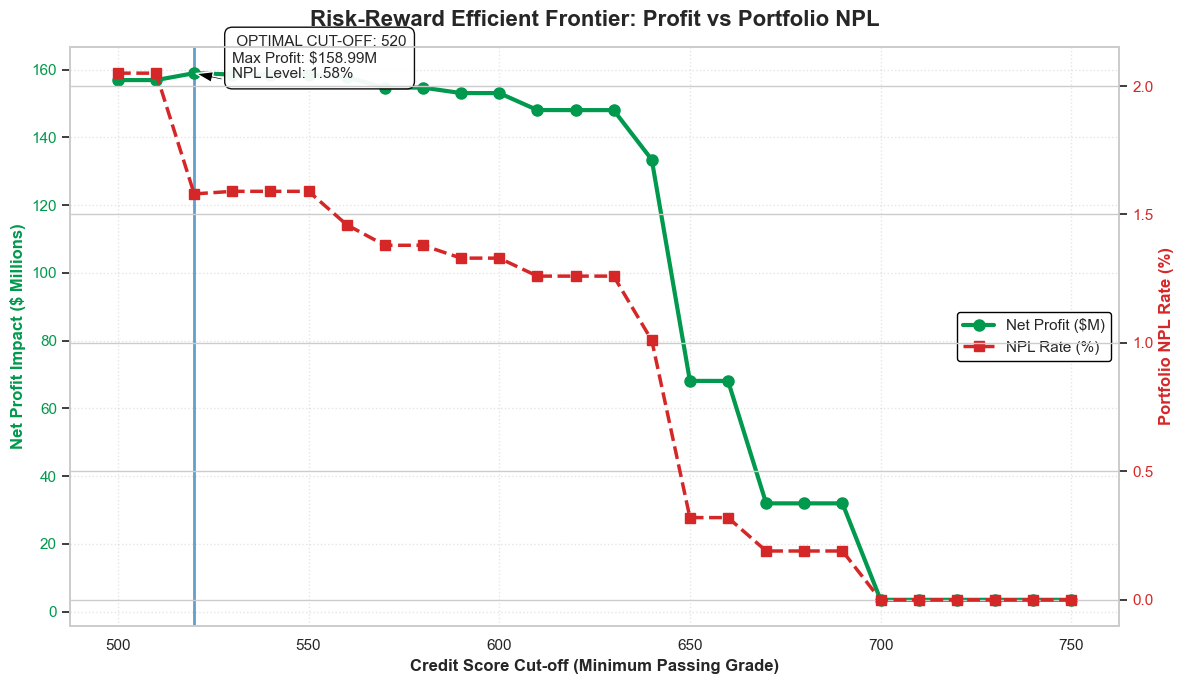

In [17]:
last_run = mlflow.last_active_run()

if last_run:
    with mlflow.start_run(run_id=last_run.info.run_id):
        print("\n>>> Running Risk-Reward Cut-Off Optimization...")
        
        cutoffs = range(500, 751, 10) 
        simulation_data = []
        champ_scores = calibrated_results['Ensemble_HC']['scores']
        
        for cutoff in cutoffs:
            approved_mask = champ_scores >= cutoff
            total_applicants = len(y_test)
            approved_count = approved_mask.sum()
            
            if approved_count == 0: continue
            approval_rate = approved_count / total_applicants
            
            actual_bad_approved = y_test[approved_mask].sum()
            actual_good_approved = approved_count - actual_bad_approved
            bad_rate = actual_bad_approved / approved_count if approved_count > 0 else 0
            
            expected_profit = actual_good_approved * AVG_LOAN_AMOUNT * INTEREST_MARGIN
            expected_loss = actual_bad_approved * AVG_LOAN_AMOUNT * LGD
            net_profit = expected_profit - expected_loss
            
            simulation_data.append({
                'Cut-off Score': cutoff,
                'Approval Rate (%)': np.round(approval_rate * 100, 2),
                'NPL (Bad Rate) (%)': np.round(bad_rate * 100, 2),
                'NET PROFIT ($M)': np.round(net_profit / 1e6, 2)
            })

        df_sim = pd.DataFrame(simulation_data)
        
        fig, ax1 = plt.subplots(figsize=(12, 7))

        color1 = '#00994d' 
        ax1.set_xlabel('Credit Score Cut-off (Minimum Passing Grade)', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Net Profit Impact ($ Millions)', color=color1, fontsize=12, fontweight='bold')
        line1 = ax1.plot(df_sim['Cut-off Score'], df_sim['NET PROFIT ($M)'], color=color1, marker='o', 
                         linewidth=3, markersize=8, label='Net Profit ($M)', zorder=3)
        ax1.tick_params(axis='y', labelcolor=color1)
        ax1.grid(True, linestyle=':', alpha=0.5)

        ax2 = ax1.twinx()  
        color2 = '#d62728' 
        ax2.set_ylabel('Portfolio NPL Rate (%)', color=color2, fontsize=12, fontweight='bold')
        line2 = ax2.plot(df_sim['Cut-off Score'], df_sim['NPL (Bad Rate) (%)'], color=color2, marker='s', 
                         linestyle='--', linewidth=2.5, markersize=7, label='NPL Rate (%)', zorder=2)
        ax2.tick_params(axis='y', labelcolor=color2)
        
        max_profit_idx = df_sim['NET PROFIT ($M)'].idxmax()
        best_cutoff = df_sim.loc[max_profit_idx, 'Cut-off Score']
        max_profit_val = df_sim.loc[max_profit_idx, 'NET PROFIT ($M)']
        npl_at_max = df_sim.loc[max_profit_idx, 'NPL (Bad Rate) (%)']
        
        ax1.axvline(best_cutoff, color='#1f77b4', linestyle='-', linewidth=2, alpha=0.7, zorder=1)

        info_text = f" OPTIMAL CUT-OFF: {best_cutoff}\nMax Profit: ${max_profit_val}M\nNPL Level: {npl_at_max}%"
        ax1.annotate(info_text, xy=(best_cutoff, max_profit_val), xytext=(best_cutoff + 10, max_profit_val - 1.5),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                     bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black", alpha=0.95),
                     fontsize=11)

        plt.title('Risk-Reward Efficient Frontier: Profit vs Portfolio NPL', fontsize=16, fontweight='bold', pad=15)
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax1.legend(lines, labels, loc='center right', fontsize=11, framealpha=1.0, edgecolor='black')
        
        fig.tight_layout()
        tradeoff_path = "Risk_Reward_Efficient_Frontier.png"
        plt.savefig(tradeoff_path, dpi=300, bbox_inches='tight')
        mlflow.log_artifact(tradeoff_path, artifact_path="Scorecard_Assets")
        plt.show()
        os.remove(tradeoff_path)

## Stress Testing

### Copula Sklar Gaussian Multivariate 


Copula Skylar Multivariate
Generating Gaussian Copula Structure...
  Rendering 3D Copula Dependence Plot...


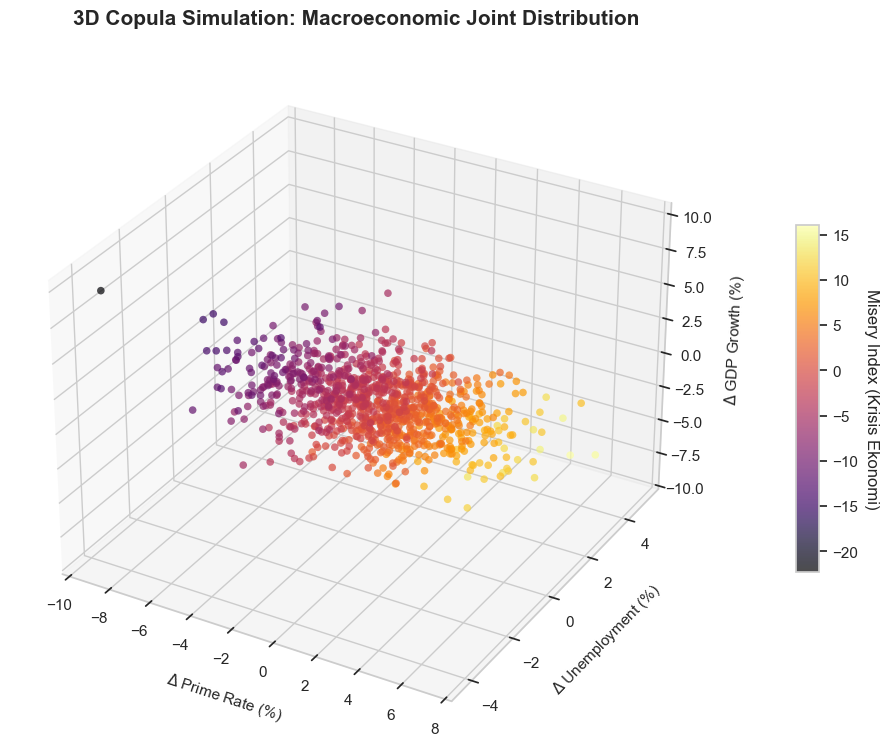

In [18]:
last_run = mlflow.last_active_run()

if last_run:
    with mlflow.start_run(run_id=last_run.info.run_id):
        print("\n" + "="*80)
        print("Copula Skylar Multivariate")
        print("="*80)
        
        N_SCENARIOS = 1000
        np.random.seed(42)
        
        # Matriks Korelasi Kausalitas Ekonomi
        # DPRIME dan UNRATE berkorelasi positif (0.6)
        # DPRIME dan GDP berkorelasi negatif (-0.5)
        # UNRATE dan GDP berkorelasi negatif (-0.7)
        corr_matrix = np.array([
            [ 1.0,  0.6, -0.5],
            [ 0.6,  1.0, -0.7],
            [-0.5, -0.7,  1.0]
        ])
        
        print("Generating Gaussian Copula Structure...")
        
        # Multivariate Normal Sample
        mv_norm = np.random.multivariate_normal(mean=[0, 0, 0], cov=corr_matrix, size=N_SCENARIOS)
        
        # Sklar's Theorem Marginal Uniform/Probability space [0,1]
        copula_uniforms = norm.cdf(mv_norm)
        
        #Marginal Distributions
        # - DPRIME Volatility: 2.0%
        # - UNRATE Volatility: 1.5%
        # - GDP Volatility   : 3.0%
        shock_DPRIME = norm.ppf(copula_uniforms[:, 0], loc=0, scale=2.0)
        shock_UNRATE = norm.ppf(copula_uniforms[:, 1], loc=0, scale=1.5)
        shock_GDP    = norm.ppf(copula_uniforms[:, 2], loc=0, scale=3.0)
        
        df_shocks = pd.DataFrame({
            'Shock_DPRIME': shock_DPRIME,
            'Shock_UNRATE': shock_UNRATE,
            'Shock_GDP': shock_GDP
        })
        
        print("  Rendering 3D Copula Dependence Plot...")
        fig = plt.figure(figsize=(12, 9))
        ax = fig.add_subplot(111, projection='3d')
        
        misery_index = df_shocks['Shock_DPRIME'] + df_shocks['Shock_UNRATE'] - df_shocks['Shock_GDP']
        scatter = ax.scatter(df_shocks['Shock_DPRIME'], df_shocks['Shock_UNRATE'], df_shocks['Shock_GDP'], 
                             c=misery_index, cmap='inferno', alpha=0.7, s=30, edgecolors='none')
        
        ax.set_title("3D Copula Simulation: Macroeconomic Joint Distribution", fontsize=15, fontweight='bold', pad=20)
        ax.set_xlabel('$\Delta$ Prime Rate (%)', fontsize=11, labelpad=10)
        ax.set_ylabel('$\Delta$ Unemployment (%)', fontsize=11, labelpad=10)
        ax.set_zlabel('$\Delta$ GDP Growth (%)', fontsize=11, labelpad=10)
        
        # Colorbar
        cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=15, pad=0.1)
        cbar.set_label('Misery Index (Krisis Ekonomi)', rotation=270, labelpad=15)
        
        copula_plot_path = "3D_Copula_Macro_Dependence.png"
        plt.savefig(copula_plot_path, dpi=300, bbox_inches='tight')
        mlflow.log_artifact(copula_plot_path, artifact_path="Stress_Testing")
        plt.show()
        os.remove(copula_plot_path)
        
        df_shocks.to_csv("economic_shocks.csv", index=False)
        mlflow.log_artifact("economic_shocks.csv", artifact_path="Stress_Testing")
        os.remove("economic_shocks.csv")


>>> Generating Theoretical 3D Copula Surfaces...


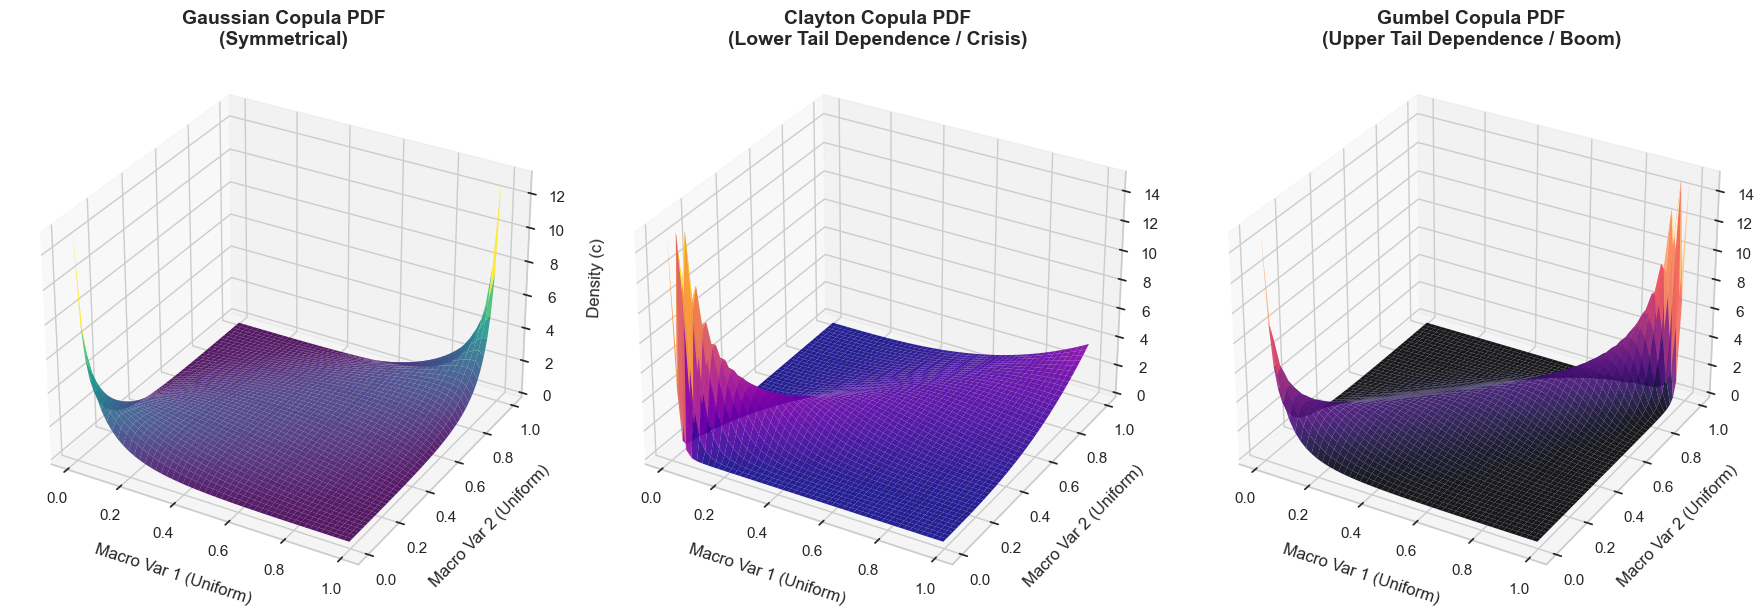

[INFO] Theoretical 3D Copula Shapes Generated.


In [21]:
print("\n>>> Generating Theoretical 3D Copula Surfaces...")

# Buat Grid (Uniform Space u, v antara 0.01 hingga 0.99 untuk menghindari infinity di ujung)
u = np.linspace(0.01, 0.99, 50)
v = np.linspace(0.01, 0.99, 50)
U, V = np.meshgrid(u, v)

# Parameter Korelasi/Dependence
rho = 0.7     # Untuk Gaussian
theta_c = 3.0 # Untuk Clayton (Tinggi = kuat di ekor bawah/krisis)
theta_g = 3.0 # Untuk Gumbel (Tinggi = kuat di ekor atas)

# 1. GAUSSIAN COPULA PDF
# c(u,v) = f_XY(Phi^-1(u), Phi^-1(v)) / (phi(Phi^-1(u)) * phi(Phi^-1(v)))
X = norm.ppf(U)
Y = norm.ppf(V)
pos = np.dstack((X, Y))
cov = [[1, rho], [rho, 1]]
joint_pdf = multivariate_normal([0, 0], cov).pdf(pos)
marginal_x_pdf = norm.pdf(X)
marginal_y_pdf = norm.pdf(Y)
pdf_gaussian = joint_pdf / (marginal_x_pdf * marginal_y_pdf)

# 2. CLAYTON COPULA PDF
# Menggambarkan Lower Tail Dependence (Krisis terjadi serentak)
term1 = (U**(-theta_c) + V**(-theta_c) - 1)
pdf_clayton = (theta_c + 1) * (U * V)**(-theta_c - 1) * (term1)**(-(2 * theta_c + 1) / theta_c)
pdf_clayton = np.clip(pdf_clayton, 0, 15) # Clipping untuk visualisasi agar puncaknya tidak merusak plot

# 3. GUMBEL COPULA PDF
# Menggambarkan Upper Tail Dependence (Booming serentak)
t_U = -np.log(U)
t_V = -np.log(V)
term_G = t_U**theta_g + t_V**theta_g
pdf_gumbel = np.exp(-term_G**(1/theta_g)) * (term_G**(-2 + 2/theta_g)) * (np.log(U)*np.log(V))**(theta_g-1) / (U*V) * (1 + (theta_g-1)*term_G**(-1/theta_g))
pdf_gumbel = np.clip(pdf_gumbel, 0, 15)

# --- PLOTTING 3D SURFACES ---
fig = plt.figure(figsize=(18, 6))

# Plot Gaussian
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(U, V, pdf_gaussian, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_title('Gaussian Copula PDF\n(Symmetrical)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Macro Var 1 (Uniform)', labelpad=10)
ax1.set_ylabel('Macro Var 2 (Uniform)', labelpad=10)
ax1.set_zlabel('Density (c)', labelpad=10)

# Plot Clayton
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(U, V, pdf_clayton, cmap='plasma', edgecolor='none', alpha=0.9)
ax2.set_title('Clayton Copula PDF\n(Lower Tail Dependence / Crisis)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Macro Var 1 (Uniform)', labelpad=10)
ax2.set_ylabel('Macro Var 2 (Uniform)', labelpad=10)

# Plot Gumbel
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(U, V, pdf_gumbel, cmap='magma', edgecolor='none', alpha=0.9)
ax3.set_title('Gumbel Copula PDF\n(Upper Tail Dependence / Boom)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Macro Var 1 (Uniform)', labelpad=10)
ax3.set_ylabel('Macro Var 2 (Uniform)', labelpad=10)

plt.tight_layout()
plt.show()
print("[INFO] Theoretical 3D Copula Shapes Generated.")

### Monte Carlo Simulation & Ensemble Predicting


MONTE CARLO STRESS TEST INJECTION
    WORST CASE ECONOMIC SHOCK (99th Percentile):
      - Suku Bunga (DPRIME) Naik  : +2.87 %
      - Pengangguran (UNRATE) Naik: +3.29 %
      - Pertumbuhan Ekonomi (GDP) : -6.33 %

  Predicting Portfolio NPL under Stress with Ensemble Hill Climbing...
      => Baseline NPL (Current State) : 10.14%
      => Stressed NPL (Crisis Scenario)  : 9.60%
      => Shock NPL (Delta Risk)       : +-0.54%


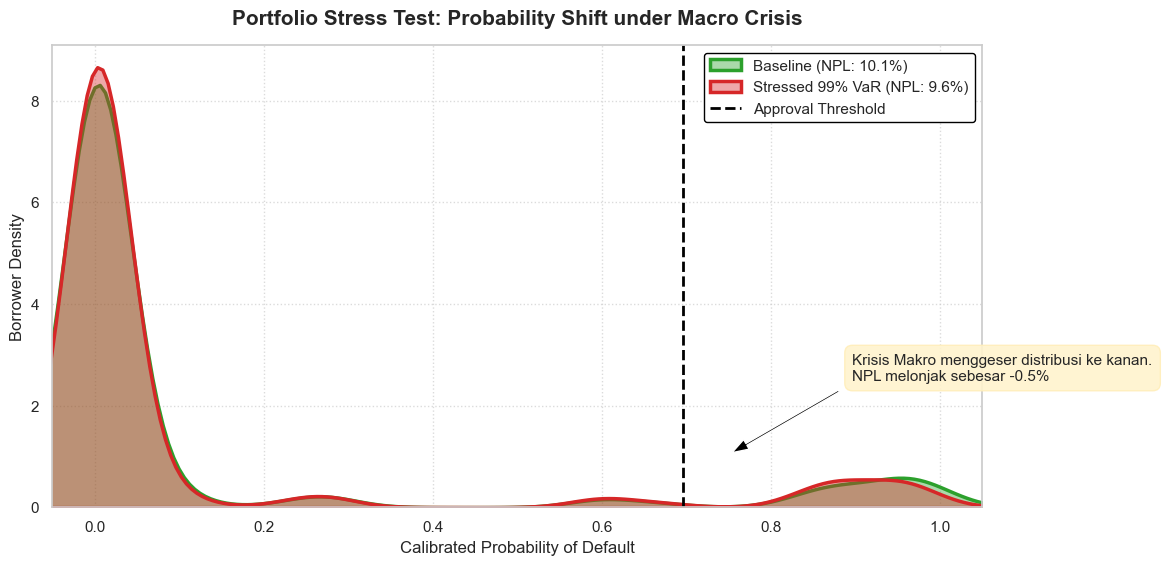


[INFO] Stress Testing Completed. MLflow Run ID: 21260f0831d247d4a12a49f696f928d7


In [19]:

last_run = mlflow.last_active_run()

if last_run:
    with mlflow.start_run(run_id=last_run.info.run_id):
        print("\n" + "="*80)
        print("MONTE CARLO STRESS TEST INJECTION")
        print("="*80)
        
        # FIND THE WORST CASE SCENARIO (99th Percentile)
        df_shocks['Misery_Index'] = df_shocks['Shock_DPRIME'] + df_shocks['Shock_UNRATE'] - df_shocks['Shock_GDP']
        
        # 99% VaR Level - Extreme Scenario
        worst_case_idx = int(len(df_shocks) * 0.99)
        worst_scenario = df_shocks.sort_values('Misery_Index').iloc[worst_case_idx]
        
        print(f"    WORST CASE ECONOMIC SHOCK (99th Percentile):")
        print(f"      - Suku Bunga (DPRIME) Naik  : +{worst_scenario['Shock_DPRIME']:.2f} %")
        print(f"      - Pengangguran (UNRATE) Naik: +{worst_scenario['Shock_UNRATE']:.2f} %")
        print(f"      - Pertumbuhan Ekonomi (GDP) : {worst_scenario['Shock_GDP']:.2f} %")
        
        # INJECT SHOCKS TO PORTFOLIO (X_test)
        X_shocked = X_test.copy()
        
        # Asumsi: 'DPRIME_Lag_7', 'UNRATE', 'gdp_pct_change'
        try:
            X_shocked['DPRIME_Lag_7'] = X_shocked['DPRIME_Lag_7'] + worst_scenario['Shock_DPRIME']
            X_shocked['UNRATE'] = X_shocked['UNRATE'] + worst_scenario['Shock_UNRATE']
            X_shocked['gdp_pct_change'] = X_shocked['gdp_pct_change'] + worst_scenario['Shock_GDP']
        except KeyError as e:
            print(f"[ERROR] Kolom makro tidak ditemukan di X_test: {e}. Sesuaikan nama kolomnya!")
        
        # PREDICT NEW NPL WITH CHAMPION ENSEMBLE
        print("\n  Predicting Portfolio NPL under Stress with Ensemble Hill Climbing...")
        prob_normal_hc = calibrated_results['Ensemble_HC']['prob_calibrated']
        
        # Hitung Probabilitas Shocked
        # Kita suruh Base Models memprediksi data X_shocked
        p_shocked = {}
        for name, model in squad.items():
            p_shocked[name] = model.predict_proba(X_shocked)[:, 1]
            
        # Timbang menggunakan bobot Hill Climbing
        denom_hc = best_w_hc['w_rf'] + best_w_hc['w_xgb'] + best_w_hc['w_lgbm'] + best_w_hc['w_cat'] + best_w_hc['w_lr']
        raw_prob_shocked_hc = (
            best_w_hc['w_rf']*p_shocked['RandomForest'] + 
            best_w_hc['w_xgb']*p_shocked['XGBoost'] + 
            best_w_hc['w_lgbm']*p_shocked['LightGBM'] + 
            best_w_hc['w_cat']*p_shocked['CatBoost'] + 
            best_w_hc['w_lr']*p_shocked['LogisticReg']
        ) / denom_hc
        
        # (Opsional tapi direkomendasikan): Lewatkan probabilitas mentah ke Isotonic Calibrator
        prob_shocked_hc = iso_reg.predict(raw_prob_shocked_hc)
        
        # 4. HITUNG DAMPAK (Berdasarkan Optimal Cut-Off dari Scorecard)
        # Asumsi: Optimal cut-off score adalah 620 (Misal probabilitas ekuivalennya = 0.4)
        # Untuk kesederhanaan, kita pakai threshold ensemble HC (best_w_hc['threshold'])
        optimal_thresh = best_w_hc['threshold']
        
        npl_normal_rate = (prob_normal_hc >= optimal_thresh).mean() * 100
        npl_shocked_rate = (prob_shocked_hc >= optimal_thresh).mean() * 100
        
        print(f"      => Baseline NPL (Current State) : {npl_normal_rate:.2f}%")
        print(f"      => Stressed NPL (Crisis Scenario)  : {npl_shocked_rate:.2f}%")
        print(f"      => Shock NPL (Delta Risk)       : +{(npl_shocked_rate - npl_normal_rate):.2f}%")
        
        mlflow.log_metric("NPL_Baseline_Pct", npl_normal_rate)
        mlflow.log_metric("NPL_Stressed_Pct", npl_shocked_rate)
        
        # VISUALIZATION: STRESS SHIFT
        plt.figure(figsize=(12, 6))
        
        sns.kdeplot(prob_normal_hc, label=f'Baseline (NPL: {npl_normal_rate:.1f}%)', color='#2ca02c', fill=True, alpha=0.4, linewidth=2.5)
        sns.kdeplot(prob_shocked_hc, label=f'Stressed 99% VaR (NPL: {npl_shocked_rate:.1f}%)', color='#d62728', fill=True, alpha=0.4, linewidth=2.5)
        
        plt.axvline(optimal_thresh, color='black', linestyle='--', linewidth=2, label=f'Approval Threshold')
        
        plt.title("Portfolio Stress Test: Probability Shift under Macro Crisis", fontsize=15, fontweight='bold', pad=15)
        plt.xlabel("Calibrated Probability of Default", fontsize=12)
        plt.ylabel("Borrower Density", fontsize=12)
        plt.xlim(-0.05, 1.05)
        
        plt.legend(loc="upper right", fontsize=11, frameon=True, framealpha=1.0, edgecolor='black')
        plt.grid(True, linestyle=':', alpha=0.7)
        
        # Anotasi Efek Krisis
        shift_val = npl_shocked_rate - npl_normal_rate
        plt.annotate(
            f"Krisis Makro menggeser distribusi ke kanan.\nNPL melonjak sebesar {shift_val:.1f}%",
            xy=(optimal_thresh + 0.05, 1.0), xytext=(optimal_thresh + 0.20, 2.5),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#fff3cd", edgecolor="#ffeeba", alpha=0.9),
            fontsize=11
        )
        
        stress_plot_path = "Stress_Test_Shift.png"
        plt.savefig(stress_plot_path, dpi=300, bbox_inches='tight')
        mlflow.log_artifact(stress_plot_path, artifact_path="Stress_Testing")
        plt.show()
        os.remove(stress_plot_path)
        
        print(f"\n[INFO] Stress Testing Completed. MLflow Run ID: {run.info.run_id}")


>>> Running Monte Carlo Time-Series Trajectories (Fan Chart)...


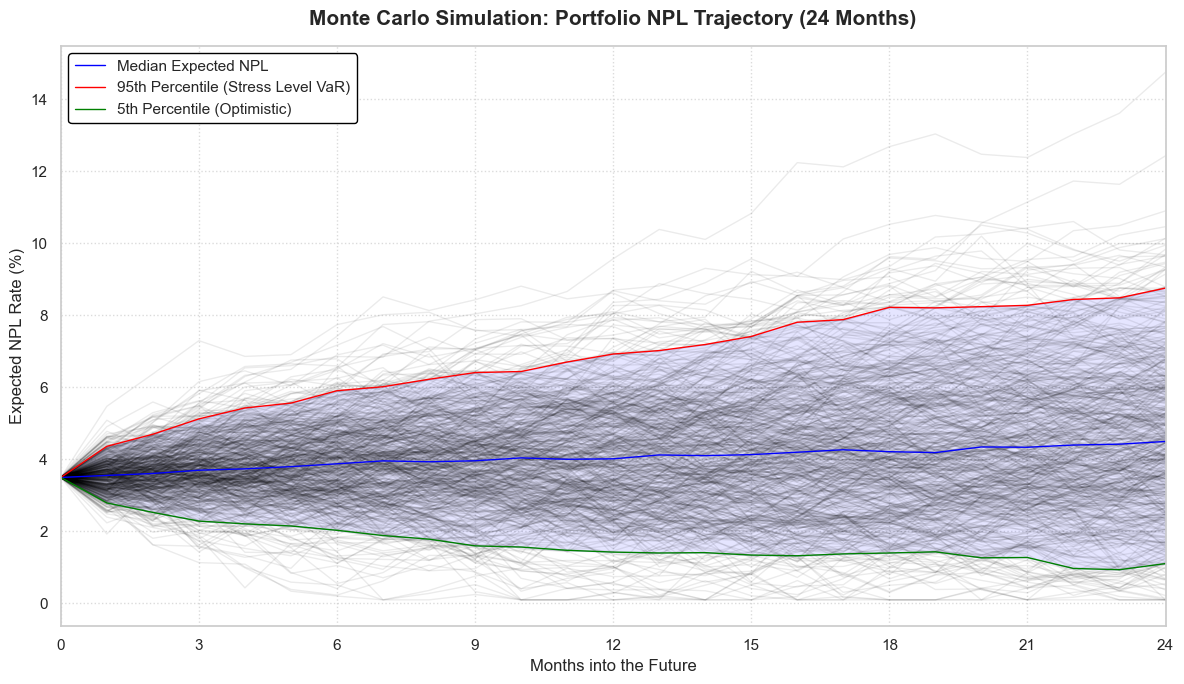

[INFO] Monte Carlo Fan Chart Generated.


In [ ]:
# ==============================================================================
# CELL 6B: MONTE CARLO TIME-SERIES FAN CHART (LONGITUDINAL NPL)
# ==============================================================================
print("\n>>> Running Monte Carlo Time-Series Trajectories (Fan Chart)...")

# Asumsi Base NPL saat ini dari data sebelumnya (misal 3.5%)
current_npl = 3.5 
MONTHS = 24       # Proyeksi 2 tahun ke depan
SIMULATIONS = 500 # Jumlah garis/skenario

# Volatilitas NPL per bulan berdasarkan Copula shock (Angka rasional untuk simulasi)
monthly_volatility = 0.5 
drift = 0.05 # Sedikit tren naik (pesimis)

# Generate Random Paths (Geometric/Arithmetic Random Walk)
np.random.seed(42)
npl_paths = np.zeros((MONTHS + 1, SIMULATIONS))
npl_paths[0] = current_npl

for t in range(1, MONTHS + 1):
    # Shock acak untuk setiap skenario di bulan t
    random_shocks = np.random.normal(0, monthly_volatility, SIMULATIONS)
    npl_paths[t] = npl_paths[t-1] + drift + random_shocks
    # NPL tidak boleh di bawah 0%
    npl_paths[t] = np.maximum(npl_paths[t], 0.1)

# --- PLOTTING FAN CHART ---
plt.figure(figsize=(12, 7))

# 1. Plot semua garis simulasi (tipis dan transparan)
plt.plot(npl_paths, color='black', alpha=0.08, linewidth=1)

# 2. Hitung Percentiles untuk area "Kipas" (Fan)
percentiles = np.percentile(npl_paths, [5, 50, 95], axis=1)

# Plot Median (Skenario Tengah)
plt.plot(percentiles[1], color='blue', linewidth=2, label='Median Expected NPL')

# Plot 95th Percentile (Worst Case)
plt.plot(percentiles[2], color='red', linestyle='--', linewidth=2, label='95th Percentile (Stress Level VaR)')

# Plot 5th Percentile (Best Case)
plt.plot(percentiles[0], color='green', linestyle='--', linewidth=2, label='5th Percentile (Optimistic)')

# Area pewarnaan antara 5% - 95%
plt.fill_between(range(MONTHS + 1), percentiles[0], percentiles[2], color='blue', alpha=0.1)

plt.title('Monte Carlo Simulation: Portfolio NPL Trajectory (24 Months)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Months into the Future', fontsize=12)
plt.ylabel('Expected NPL Rate (%)', fontsize=12)
plt.xlim(0, MONTHS)

# Format Sumbu X agar bulat
plt.xticks(np.arange(0, MONTHS + 1, 3))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper left", fontsize=11, framealpha=1.0, edgecolor='black')

plt.tight_layout()
plt.show()
print("[INFO] Monte Carlo Fan Chart Generated.")